## Business Context

Tech IT is a technology training organization operating multiple training
centers across Nigeria. The organization offers professional programs in
Web Development, Data Science, Cybersecurity, and UI/UX Design.

The business wants to understand how student enrollment, payment behavior,
referral sources, and student characteristics relate to course completion
and dropout risk.

This analysis uses enrollment, student, payment, center, and course data to
identify operational and financial patterns that can support better student
retention and payment management decisions.

## Project Objectives

The analysis aims to answer the following business questions:

1. What proportion of enrolled students complete their courses?
2. Which training centers have the strongest and weakest completion rates?
3. Which referral sources produce students with better completion outcomes?
4. How does initial deposit level relate to student risk?
5. Which student characteristics are associated with higher dropout risk?
6. How significant are payment delays, defaults, and overpayments?
7. Which students or enrollment groups may require early intervention?
8. What actions can management take to improve completion and payment
   performance?

## Load Datasets

The project contains five related datasets covering students, courses, training centers, enrollments, and payments.

These datasets will be loaded separately first. They will later be related through their primary and foreign keys to support the analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# Load datasets
enrollments = pd.read_csv('../data/raw/tech_it_enrollments.csv')
students = pd.read_csv('../data/raw/tech_it_students.csv')
payments = pd.read_csv('../data/raw/tech_it_payments.csv')
centers = pd.read_csv('../data/raw/tech_it_centers.csv')
courses = pd.read_csv('../data/raw/tech_it_courses.csv')


## 3. Initial Data Inspection

Before performing any analysis, the structure and quality of each dataset are examined.

The inspection covers:

- First few records
- Number of rows and columns
- Column names
- Data types
- Missing values
- Duplicate rows

In [2]:
datasets = [
    ("Students", students),
    ("Courses", courses),
    ("Centers", centers),
    ("Enrollments", enrollments),
    ("Payments", payments)
]

for name, df in datasets:
    print(f"\n{'=' * 50}")
    print(f"DATASET: {name}")
    print(f"{'=' * 50}")
    
    print("\nFirst 5 Rows:")
    print(df.head())
    
    print("\nShape:")
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")
    
    print("\nColumn Names:")
    print(list(df.columns))
    
    print("\nData Types:")
    print(df.dtypes)
    
    print("\nMissing Values:")
    print(df.isnull().sum())
    
    print("\nDuplicate Rows:")
    print(df.duplicated().sum())


DATASET: Students

First 5 Rows:
  student_id            full_name                    email       phone  \
0    STU-001  Chukwuemeka Ibrahim  chukwuemeka.i@email.com  8031234567   
1    STU-002          Amina Bello    amina.bello@email.com  7045678901   
2    STU-003    Oluwaseun Adeyemi    oluwaseun.a@email.com  9087654321   
3    STU-004     Fatima Abdullahi     fatima.abd@email.com  8123456789   
4    STU-005            Emeka Obi      emeka.obi@email.com  7099887766   

          dob  gender education_level   employment_status  \
0  1995-03-15    Male             BSc  Employed Full-time   
1  1998-07-22  Female             HND          Unemployed   
2  1992-11-05    Male            SSCE  Employed Part-time   
3  2000-01-18  Female             BSc             Student   
4  1990-05-30    Male             OND  Employed Full-time   

  monthly_income_range referral_source registration_date  
0            150k-250k        Referral        2026-01-10  
1            Below 50k    Social Med

## Data Type Preparation

Date fields are converted to datetime format so that they can be used correctly for date-based analysis such as:

- Enrollment duration
- Payment delays
- Completion time
- Enrollment trends

In [3]:
date_columns = {
    "Enrollments": [
        "enrollment_date",
        "start_date",
        "expected_end_date",
        "actual_end_date"
    ],
    "Students": [
        "dob",
        "registration_date"
    ],
    "Payments": [
        "due_date",
        "payment_date"
    ]
}

for name, columns in date_columns.items():
    df = dict(datasets)[name]

    for col in columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

    print(f"\n{name}")

    for col in columns:
        print(f"{col} | Missing/NaT: {df[col].isna().sum()}")
        
# for name, df in datasets:
#     for col in df.columns:
#         if "date" in col.lower() or "time" in col.lower() or "dob" in col.lower():
#             print(f"{name}: Converting {col}")
#             df[col] = pd.to_datetime(df[col], errors="coerce")


Enrollments
enrollment_date | Missing/NaT: 0
start_date | Missing/NaT: 0
expected_end_date | Missing/NaT: 0
actual_end_date | Missing/NaT: 17

Students
dob | Missing/NaT: 0
registration_date | Missing/NaT: 0

Payments
due_date | Missing/NaT: 0
payment_date | Missing/NaT: 23


## Data Quality Validation

The datasets are checked for structural and referential integrity before they are combined.

The validation checks include:

- Duplicate records
- Missing primary keys
- Invalid foreign-key references
- Payment inconsistencies
- Status/date inconsistencies

In [4]:
duplicate_check = pd.DataFrame([
    {
        "dataset": name,
        "duplicate_rows": df.duplicated().sum()
    }
    for name, df in datasets
])

duplicate_check

,dataset,duplicate_rows
0,Students,0
1,Courses,0
2,Centers,0
3,Enrollments,0
4,Payments,0


### Duplicate Check

No duplicate rows were identified in any of the five datasets.

This indicates that there are no exact duplicate records at the row level.
However, duplicate checking at the row level does not guarantee that all
business keys are unique, so key-level validation will also be performed.

### Missing primary keys

For a proper primary key:

- Duplicate Keys = 0
- Null Keys = 0

If either is greater than zero, then the assumption about the grain needs to be investigated.

In [5]:
primary_keys = {
    "Students": ("student_id", students),
    "Courses": ("course_id", courses),
    "Centers": ("center_id", centers),
    "Enrollments": ("enrollment_id", enrollments),
    "Payments": ("payment_id", payments)
}

for name, (key, df) in primary_keys.items():
    print(f"\n{'=' * 50}")
    print(f"DATASET: {name}")
    print(f"{'=' * 50}")
    
    print(f"Primary Key: {key}")
    print(f"Duplicate Keys: {df[key].duplicated().sum()}")
    print(f"Null Keys: {df[key].isna().sum()}")


DATASET: Students
Primary Key: student_id
Duplicate Keys: 0
Null Keys: 0

DATASET: Courses
Primary Key: course_id
Duplicate Keys: 0
Null Keys: 0

DATASET: Centers
Primary Key: center_id
Duplicate Keys: 0
Null Keys: 0

DATASET: Enrollments
Primary Key: enrollment_id
Duplicate Keys: 0
Null Keys: 0

DATASET: Payments
Primary Key: payment_id
Duplicate Keys: 0
Null Keys: 0


### Invalid foreign-key references 

The relationships between the datasets are validated before joining them.

Expected relationships:

- Students -> Enrollments
- Courses -> Enrollments
- Centers -> Enrollments
- Enrollments -> Payments

Every foreign key should correspond to an existing primary key in the referenced table.

In [6]:
invalid_student_refs = enrollments[
    ~enrollments["student_id"].isin(students["student_id"])
]

invalid_course_refs = enrollments[
    ~enrollments["course_id"].isin(courses["course_id"])
]

invalid_center_refs = enrollments[
    ~enrollments["center_id"].isin(centers["center_id"])
]

invalid_enrollment_refs = payments[
    ~payments["enrollment_id"].isin(enrollments["enrollment_id"])
]

print(f"Invalid student references: {len(invalid_student_refs)}")
print(f"Invalid course references: {len(invalid_course_refs)}")
print(f"Invalid center references: {len(invalid_center_refs)}")
print(f"Invalid enrollment references in payments: {len(invalid_enrollment_refs)}")

Invalid student references: 0
Invalid course references: 0
Invalid center references: 0
Invalid enrollment references in payments: 0


### Interpretation

All foreign-key relationships passed validation.

Every student referenced by an enrollment exists in the Students dataset,
every course and center referenced by an enrollment exists in their
respective reference datasets, and every payment references a valid
enrollment.

No orphan records were identified.

### Payment Inconsistencies

In [7]:
overpayments = payments[
    payments["amount_paid"] > payments["amount_due"]
].copy()

overpayments["overpayment_amount"] = (
    overpayments["amount_paid"] - overpayments["amount_due"]
)

overpayments[
    [
        "payment_id",
        "enrollment_id",
        "amount_due",
        "amount_paid",
        "overpayment_amount"
    ]
]

,payment_id,enrollment_id,amount_due,amount_paid,overpayment_amount
0,1,ENR-001,"175,000.00","184,108.42","9,108.42"
63,64,ENR-025,"104,000.00","110,726.96","6,726.96"
91,92,ENR-033,"136,000.00","141,366.90","5,366.90"


### Status/date inconsistencies

In [8]:
paid_without_date = payments[
    (payments["payment_status"] == "paid") &
    (payments["payment_date"].isna())
]

completed_without_end = enrollments[
    (enrollments["status"] == "completed") &
    (enrollments["actual_end_date"].isna())
]

active_with_end = enrollments[
    (enrollments["status"] == "active") &
    (enrollments["actual_end_date"].notna())
]

print(f"Paid payments with no payment date: {len(paid_without_date)}")
print(f"Completed enrollments without actual end date: {len(completed_without_end)}")
print(f"Active enrollments with actual end date: {len(active_with_end)}")

Paid payments with no payment date: 0
Completed enrollments without actual end date: 0
Active enrollments with actual end date: 0


## Grain & Relationship Validation

Before joining the datasets, the grain of each table is established.

The grain describes what one row represents.

Expected grain:

|Dataset | Grain | Primary Key |
| --- | --- | --- |
|students | One row = one student | student_id |
|courses | One row = one course | course_id |
|centers | One row = one training center| center_id |
|enrollments | One row = one student enrollment in one course | enrollment_id |
|payments | One row = one installment/payment record for an enrollment | payment_id |

Understanding the grain prevents accidental row multiplication during joins.

## One-to-many Relationship

### Grain 1

Student -> Enrollment

We expect:

One student -> potentially many enrollments

Intended grain

One row = one enrollment.

Therefore, joining students to enrollments should not increase the number of enrollment rows.

In [9]:
student_enrollment_counts = (
    enrollments
    .groupby("student_id")
    .size()
    .sort_values(ascending=False)
)

print(student_enrollment_counts.head(10))

print(
    f"Students with multiple enrollments: "
    f"{(student_enrollment_counts > 1).sum()}"
)

student_id
STU-003    3
STU-002    2
STU-005    2
STU-017    2
STU-018    2
STU-009    2
STU-029    2
STU-023    2
STU-022    2
STU-014    2
dtype: int64
Students with multiple enrollments: 12


**TEST**

In [10]:
print("Enrollments before join:", len(enrollments))

enrollment_student = enrollments.merge(
    students,
    on="student_id",
    how="left",
    validate="many_to_one"
)

print("Rows after join:", len(enrollment_student))

print(
    "Unique enrollment IDs After Join:",
    enrollment_student["enrollment_id"].nunique()
)

print(
    "Total rows:",
    len(enrollment_student)
)

Enrollments before join: 35
Rows after join: 35
Unique enrollment IDs After Join: 35
Total rows: 35


### Grain 2

Enrollment -> Payment

We expect:

One enrollment -> potentially many payments

Intended grain

One row = one payment.

Therefore, joining payments to enrollments should not increase the number of enrollment rows.

In [11]:
enrollment_payment_counts = (
    payments
    .groupby("enrollment_id")
    .size()
    .sort_values(ascending=False)
)

print(enrollment_payment_counts.head(10))

print(
    f"Enrollments with multiple payment records: "
    f"{(enrollment_payment_counts > 1).sum()}"
)

enrollment_id
ENR-029    6
ENR-035    6
ENR-007    6
ENR-011    5
ENR-028    5
ENR-008    5
ENR-002    3
ENR-033    3
ENR-003    3
ENR-016    3
dtype: int64
Enrollments with multiple payment records: 33


**TEST**

In [12]:
print("Enrollments before join:", len(payments))

payment_enrollment = payments.merge(
    enrollments,
    on="enrollment_id",
    how="left",
    validate="many_to_one"
)

print("Rows after join:", len(payment_enrollment))

print(
    "Unique enrollment IDs After Join:",
    payment_enrollment["payment_id"].nunique()
)

print(
    "Total rows:",
    len(payment_enrollment)
)

Enrollments before join: 101
Rows after join: 101
Unique enrollment IDs After Join: 101
Total rows: 101


### Grain 3

Course -> Enrollment

We expect:

One Course -> potentially many enrollments

Intended grain

One row = one enrollment.

Therefore, joining courses to enrollments should not increase the number of enrollment rows.

In [13]:
course_enrollment_counts = (
    enrollments
    .groupby("course_id")
    .size()
    .sort_values(ascending=False)
)

print(course_enrollment_counts.head(10))

print(
    f"Courses with multiple enrollments: "
    f"{(course_enrollment_counts > 1).sum()}"
)

course_id
CRS-001    18
CRS-002    10
CRS-003     5
CRS-004     2
dtype: int64
Courses with multiple enrollments: 4


**TEST**

In [14]:
print("Enrollments before join:", len(enrollments))

enrollment_course = enrollments.merge(
    courses,
    on="course_id",
    how="left",
    validate="many_to_one"
)

print("Rows after join:", len(enrollment_course))

print(
    "Unique enrollment IDs After Join:",
    enrollment_course["enrollment_id"].nunique()
)

print(
    "Total rows:",
    len(enrollment_course)
)

Enrollments before join: 35
Rows after join: 35
Unique enrollment IDs After Join: 35
Total rows: 35


### Grain 4

Center -> Enrollment

We expect:

One Center -> potentially many enrollments

Intended grain

One row = one enrollment.

Therefore, joining centers to enrollments should not increase the number of enrollment rows.

In [15]:
center_enrollment_counts = (
    enrollments
    .groupby("center_id")
    .size()
    .sort_values(ascending=False)
)

print(center_enrollment_counts.head(10))

print(
    f"Centers with multiple enrollments: "
    f"{(center_enrollment_counts > 1).sum()}"
)

center_id
CEN-001    16
CEN-002    11
CEN-003     8
dtype: int64
Centers with multiple enrollments: 3


**TEST**

In [16]:
print("Enrollments before join:", len(enrollments))

enrollment_center = enrollments.merge(
    centers,
    on="center_id",
    how="left",
    validate="many_to_one"
)

print("Rows after join:", len(enrollment_center))

print(
    "Unique enrollment IDs After Join:",
    enrollment_center["enrollment_id"].nunique()
)

print(
    "Total rows:",
    len(enrollment_center)
)

Enrollments before join: 35
Rows after join: 35
Unique enrollment IDs After Join: 35
Total rows: 35


### Multiple Join Grain Test

Because we know the enrollment grain is the central table for students, courses, and centers, we can safely extend the enrollment-level analytical table.

We want:

`Original enrollment rows = Joined rows = Unique enrollment IDs`

If that happens, we know that:

`enrollment_analysis` is still at enrollment grain.

In [17]:
enrollment_level = (
    enrollments
    .merge(
        students,
        on="student_id",
        how="left",
        validate="many_to_one"
    )
    .merge(
        courses,
        on="course_id",
        how="left",
        validate="many_to_one"
    )
    .merge(
        centers,
        on="center_id",
        how="left",
        validate="many_to_one"
    )
)

print("Original enrollment rows:", len(enrollments))
print("Joined rows:", len(enrollment_level))
print(
    "Unique enrollment IDs:",
    enrollment_level["enrollment_id"].nunique()
)

Original enrollment rows: 35
Joined rows: 35
Unique enrollment IDs: 35


***Why we did not join payments above***

Because we will potentially get:

ENR-001 → Payment 1
ENR-001 → Payment 2
ENR-002 → Payment 1
ENR-002 → Payment 2
ENR-002 → Payment 3
...

Our grain will then change from:

> One row = one enrollment

to:

>One row = one payment/installment

Breaking the structure, which is not necessarily wrong but it becomes dangerous if we then calculate something like the sum of `total_fee`. This is because an enrollment's `total_fee` would appear once for every payment associated with it.

ENR-002

total_fee = 400,000

Payment 1 → 400,000

Payment 2 → 400,000

Payment 3 → 400,000

A naive sum would count `1,200,000` instead of `400,000`

This is exactly why grain must come before analysis

***MY ANALYTICAL STRATEGY***

Maintain separate analytical grains rather than forcing everything into one giant table.

**Enrollment-level table**

> enrollment_analysis

Grain:

> One row = one enrollment

Contains information from:

> Enrollments + Students + Courses + Centers

Useful for:
- enrollment analysis
- dropout analysis
- student characteristics
- course performance
- center performance
- demographic analysis
- risk analysis

**Payment-level table**

`payment_analysis`

Grain:

`One row = one payment/installment`

Contains information from:

`Payments + Enrollments + Students + Courses + Centers`

Useful for:
- payment performance
- outstanding balances
- default rates
- late payments
- collection performance
- payment-plan analysis

### Interpretation

**Dataset Relationships**

The datasets follow a relational structure:

- One student can have many enrollments.
- One course can have many enrollments.
- One center can have many enrollments.
- One enrollment can have many payment records.

Therefore:

Students -> Enrollments -> Payments

Courses  -> Enrollments

Centers  -> Enrollments

The enrollment table is the central transactional table for enrollment-level analysis,
while the payments table represents a lower-grain installment-level transaction.

## Analytical Dataset

The validated datasets are combined into an enrollment-level analytical dataset.

The target grain is:

> One row = one enrollment.

Payment-level information is therefore aggregated before being joined to the enrollment table. This prevents multiple payment records from multiplying enrollment rows.

In [18]:
enrollment_analysis = enrollment_level.copy()

enrollment_analysis.head()

,enrollment_id,student_id,course_id,center_id,enrollment_date,start_date,expected_end_date,actual_end_date,status,deposit_amount,payment_plan,admission_staff,full_name,email,phone,dob,gender,education_level,employment_status,monthly_income_range,referral_source,registration_date,course_code,course_name,category,duration_weeks,total_fee,description,center_name,city,state,manager_name,year_opened
0,ENR-001,STU-001,CRS-001,CEN-001,2026-01-10,2026-01-20,2026-07-14,NaT,active,"175,000.00",2_installments,John Doe,Chukwuemeka Ibrahim,chukwuemeka.i@email.com,8031234567,1995-03-15,Male,BSc,Employed Full-time,150k-250k,Referral,2026-01-10,WD-101,Full Stack Web Development,Web Development,24,"350,000.00",Comprehensive MERN stack program,TechHub Ikeja,Lagos,Lagos State,Mr. Adebayo Johnson,2019
1,ENR-002,STU-002,CRS-002,CEN-002,2026-01-15,2026-01-25,2026-06-12,NaT,active,"80,000.00",3_installments,Jane Smith,Amina Bello,amina.bello@email.com,7045678901,1998-07-22,Female,HND,Unemployed,Below 50k,Social Media,2026-01-15,DS-201,Data Science & Analytics,Data Science,20,"400,000.00","Python, SQL, ML fundamentals",CodeBase Abuja,Abuja,FCT,Mrs. Ngozi Okonkwo,2021
2,ENR-003,STU-003,CRS-001,CEN-001,2026-02-01,2026-02-10,2026-08-04,NaT,dropped_out,"50,000.00",3_installments,John Doe,Oluwaseun Adeyemi,oluwaseun.a@email.com,9087654321,1992-11-05,Male,SSCE,Employed Part-time,50k-100k,Walk-in,2026-02-01,WD-101,Full Stack Web Development,Web Development,24,"350,000.00",Comprehensive MERN stack program,TechHub Ikeja,Lagos,Lagos State,Mr. Adebayo Johnson,2019
3,ENR-004,STU-004,CRS-004,CEN-003,2026-02-10,2026-02-15,2026-05-10,NaT,active,"125,000.00",2_installments,Mary Johnson,Fatima Abdullahi,fatima.abd@email.com,8123456789,2000-01-18,Female,BSc,Student,Below 50k,Referral,2026-02-10,UX-401,UI/UX Design Professional,Design,12,"250,000.00","Figma, prototyping, user research",DevCenter PH,Port Harcourt,Rivers State,Mr. Chinedu Okafor,2020
4,ENR-005,STU-005,CRS-003,CEN-002,2026-02-15,2026-02-20,2026-06-12,NaT,active,"150,000.00",2_installments,Jane Smith,Emeka Obi,emeka.obi@email.com,7099887766,1990-05-30,Male,OND,Employed Full-time,100k-150k,Social Media,2026-02-15,CS-301,Cybersecurity Fundamentals,Cybersecurity,16,"300,000.00",Network security and ethical hacking,CodeBase Abuja,Abuja,FCT,Mrs. Ngozi Okonkwo,2021


In [19]:
# Verify its grain one final time

print("Rows:", len(enrollment_analysis))
print(
    "Unique enrollments:",
    enrollment_analysis["enrollment_id"].nunique()
)

assert (
    enrollment_analysis["enrollment_id"].nunique()
    == len(enrollment_analysis)
)

print("Grain validation passed: one row per enrollment.")

Rows: 35
Unique enrollments: 35
Grain validation passed: one row per enrollment.


## Analytical Dataset Overview

The analytical dataset combines enrollment, student, course, center, and payment information at the enrollment grain.

This dataset will be used for the exploratory analysis and business questions that follow.

In [20]:
print("Shape:", enrollment_analysis.shape)

print("\nColumns:")
print(list(enrollment_analysis.columns))

print("\nData Types:")
print(enrollment_analysis.dtypes)

print("\nMissing Values:")
print(enrollment_analysis.isnull().sum())

Shape: (35, 33)

Columns:
['enrollment_id', 'student_id', 'course_id', 'center_id', 'enrollment_date', 'start_date', 'expected_end_date', 'actual_end_date', 'status', 'deposit_amount', 'payment_plan', 'admission_staff', 'full_name', 'email', 'phone', 'dob', 'gender', 'education_level', 'employment_status', 'monthly_income_range', 'referral_source', 'registration_date', 'course_code', 'course_name', 'category', 'duration_weeks', 'total_fee', 'description', 'center_name', 'city', 'state', 'manager_name', 'year_opened']

Data Types:
enrollment_id                      str
student_id                         str
course_id                          str
center_id                          str
enrollment_date         datetime64[us]
start_date              datetime64[us]
expected_end_date       datetime64[us]
actual_end_date         datetime64[us]
status                             str
deposit_amount                 float64
payment_plan                       str
admission_staff                    

In [ ]:
from pathlib import Path

# save enrolment analysis to data processed folder
processed_path = Path("../data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

enrollment_analysis.to_csv(
    processed_path / "enrollment_analysis.csv",
    index=False
)

print("Saved to:", processed_path / "enrollment_analysis.csv")

Saved to: ..\data\processed\enrollment_analysis.csv


## Exploratory Data Analysis

The exploratory analysis examines enrollment patterns, student characteristics, course performance, center performance, payment behaviour, and enrollment outcomes.

The objective is to identify patterns that can guide the later business analysis and recommendations.

### Enrollment Status

We first examine the distribution of enrollment outcomes to understand how many enrollments are active, completed, dropped out, or suspended.

In [22]:
status_counts = (
    enrollment_analysis["status"]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="enrollments")
)

status_counts

,status,enrollments
0,active,16
1,dropped_out,9
2,completed,9
3,suspended,1


In [23]:
status_counts["percentage"] = (
    status_counts["enrollments"]
    / status_counts["enrollments"].sum()
    * 100
).round(2)

status_counts

,status,enrollments,percentage
0,active,16,45.71
1,dropped_out,9,25.71
2,completed,9,25.71
3,suspended,1,2.86


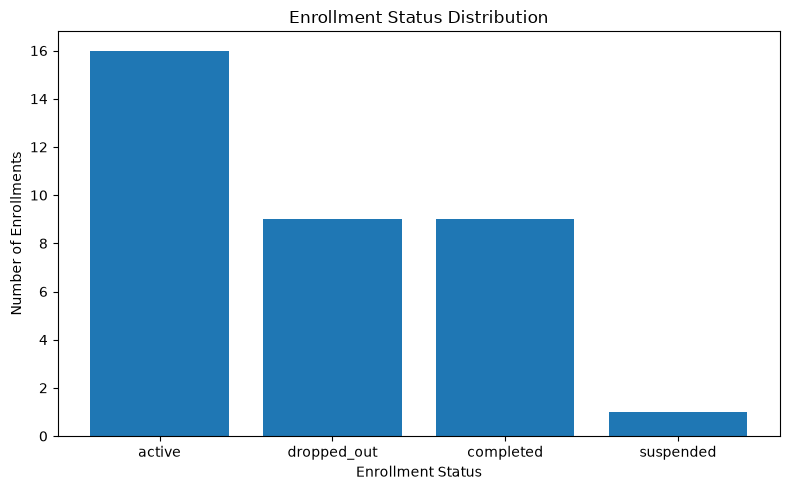

In [24]:
# plot enrollment status distribution
plt.figure(figsize=(8, 5))

plt.bar(
    status_counts["status"],
    status_counts["enrollments"]
)

plt.title("Enrollment Status Distribution")
plt.xlabel("Enrollment Status")
plt.ylabel("Number of Enrollments")
# plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Enrollment by Course

Course-level enrollment is examined to determine which programmes attract the greatest number of students.

In [25]:
course_enrollment = (
    enrollment_analysis
    .groupby(["course_name", "category"])
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values("enrollments", ascending=False)
)

course_enrollment

,course_name,category,enrollments,students
2,Full Stack Web Development,Web Development,18,14
1,Data Science & Analytics,Data Science,10,9
0,Cybersecurity Fundamentals,Cybersecurity,5,4
3,UI/UX Design Professional,Design,2,2


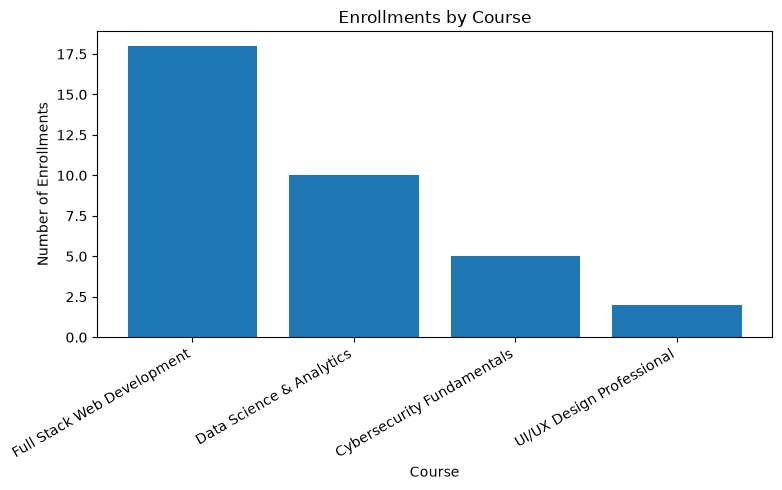

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    course_enrollment["course_name"],
    course_enrollment["enrollments"]
)

plt.title("Enrollments by Course")
plt.xlabel("Course")
plt.ylabel("Number of Enrollments")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

### Enrollment by Training Center

Enrollment volume is compared across training centres to identify differences in demand between locations.

In [27]:
center_enrollment = (
    enrollment_analysis
    .groupby(["center_name", "city", "state"])
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values("enrollments", ascending=False)
)

center_enrollment

,center_name,city,state,enrollments,students
2,TechHub Ikeja,Lagos,Lagos State,16,12
0,CodeBase Abuja,Abuja,FCT,11,9
1,DevCenter PH,Port Harcourt,Rivers State,8,8


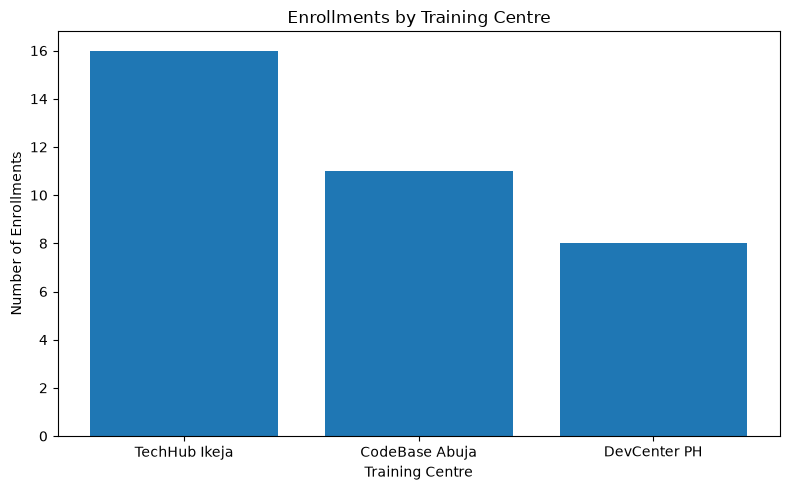

In [28]:
plt.figure(figsize=(8, 5))

plt.bar(
    center_enrollment["center_name"],
    center_enrollment["enrollments"]
)

plt.title("Enrollments by Training Centre")
plt.xlabel("Training Centre")
plt.ylabel("Number of Enrollments")

plt.tight_layout()
plt.show()

### Enrollment Trend

Monthly enrollment trends are examined to identify changes in student demand over time.

In [29]:
monthly_enrollments = (
    enrollment_analysis
    .assign(
        enrollment_month=lambda x:
        x["enrollment_date"].dt.to_period("M")
    )
    .groupby("enrollment_month")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
)

monthly_enrollments

,enrollment_month,enrollments,students
0,2025-07,3,3
1,2025-08,1,1
2,2025-10,4,4
3,2025-11,4,4
4,2025-12,2,2
5,2026-01,3,3
6,2026-02,4,4
7,2026-03,8,8
8,2026-05,1,1
9,2026-06,5,5


In [30]:
# convert period for ploting

monthly_enrollments["enrollment_month"] = (
    monthly_enrollments["enrollment_month"]
    .astype(str)
)

monthly_enrollments["enrollment_month"].dtype

<StringDtype(storage='python', na_value=nan)>

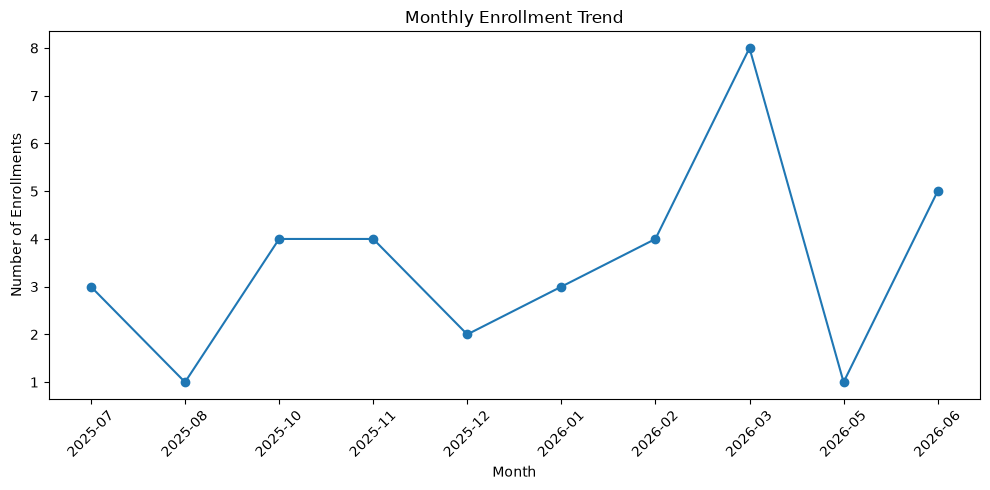

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_enrollments["enrollment_month"],
    monthly_enrollments["enrollments"],
    marker="o"
)

plt.title("Monthly Enrollment Trend")
plt.xlabel("Month")
plt.ylabel("Number of Enrollments")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Student Employment Status

Student employment status is examined to understand the composition of the learner population.

In [32]:
employment_distribution = (
    enrollment_analysis
    .groupby("employment_status")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values("enrollments", ascending=False)
)

employment_distribution

,employment_status,enrollments,students
1,Employed Part-time,11,6
2,Student,9,6
3,Unemployed,8,6
0,Employed Full-time,7,4


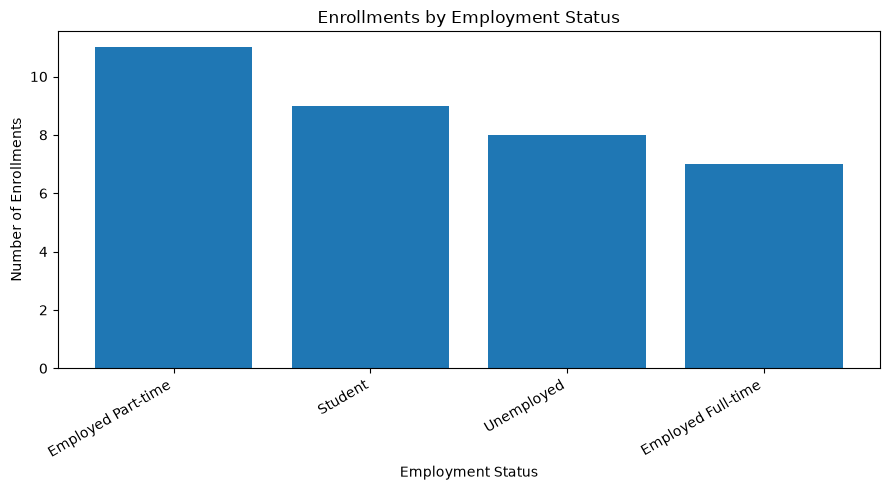

In [33]:
plt.figure(figsize=(9, 5))

plt.bar(
    employment_distribution["employment_status"],
    employment_distribution["enrollments"]
)

plt.title("Enrollments by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Number of Enrollments")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

### Referral Source

The distribution of enrollment sources is examined to understand which channels contribute the most enrollments.

In [34]:
referral_distribution = (
    enrollment_analysis
    .groupby("referral_source")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values("enrollments", ascending=False)
)

referral_distribution

,referral_source,enrollments,students
2,Walk-in,15,9
1,Social Media,10,6
3,Website,6,3
0,Referral,4,4


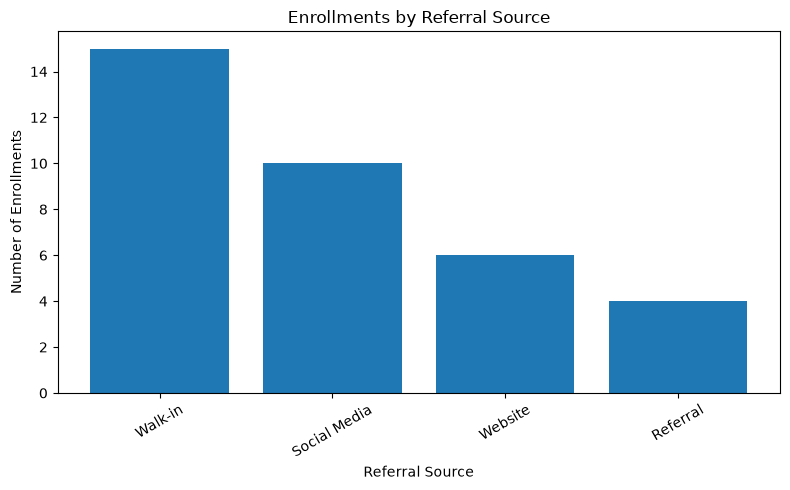

In [35]:
plt.figure(figsize=(8, 5))

plt.bar(
    referral_distribution["referral_source"],
    referral_distribution["enrollments"]
)

plt.title("Enrollments by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Number of Enrollments")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Payment Plan Distribution

The distribution of payment plans is examined to understand how students prefer to finance their training.

In [36]:
payment_plan_distribution = (
    enrollment_analysis
    .groupby("payment_plan")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values("enrollments", ascending=False)
)

payment_plan_distribution

,payment_plan,enrollments,students
0,2_installments,15,15
1,3_installments,12,10
3,monthly,6,6
2,full_payment,2,2


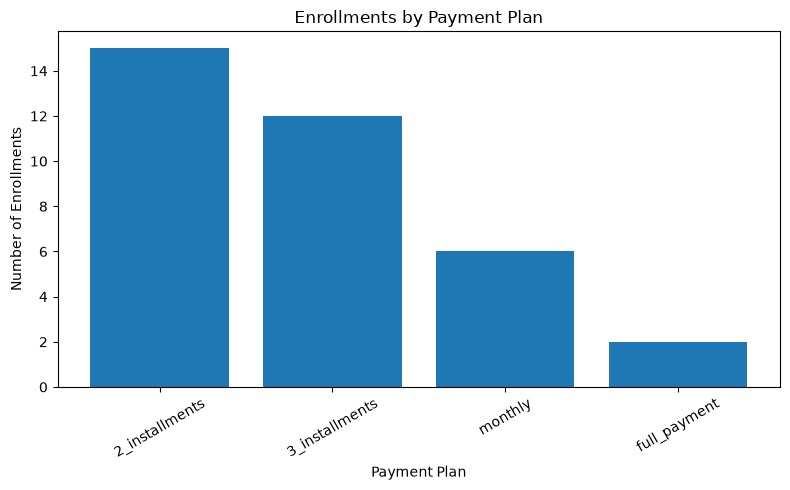

In [37]:
plt.figure(figsize=(8, 5))

plt.bar(
    payment_plan_distribution["payment_plan"],
    payment_plan_distribution["enrollments"]
)

plt.title("Enrollments by Payment Plan")
plt.xlabel("Payment Plan")
plt.ylabel("Number of Enrollments")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### EDA Findings

The exploratory analysis identified several patterns that require further investigation:

- Active enrollments represent 45.71% of all enrollments, while 25.71% have been completed and 25.71% have dropped out.
- Full Stack Web Development has the highest enrollment volume, accounting for 18 of the 35 enrollments.
- TechHub Ikeja has the highest enrollment volume among the three training centres, with 16 enrollments.
- Enrollment volume increased noticeably in March 2026, when 8 enrollments were recorded.
- Employed part-time students account for the highest number of enrollments, followed by students and unemployed learners.
- Walk-in is the largest enrollment source, followed by Social Media.
- Two-installment plans are the most common payment arrangement, followed by three-installment plans.

These observations describe the composition of the dataset but do not establish why differences occur. Further analysis will therefore examine enrollment outcomes, dropout patterns, and payment behaviour across these groups.

## Business Analysis 1: Enrollment Outcomes

### Enrollment Outcome Distribution

**Business Question:** What proportion of finalized enrollments were completed or dropped out?

Active and suspended enrollments are excluded from the dropout calculation because their final outcomes have not yet been determined.

The dropout rate is calculated using only finalized enrollments:

**Dropout Rate = Dropped Out / (Completed + Dropped Out) × 100**

In [38]:
# Select only finalized enrollment outcomes
finalized = enrollment_analysis[
    enrollment_analysis["status"].isin(["completed", "dropped_out"])
]

outcome_summary = (
    finalized["status"]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="enrollments")
)

outcome_summary["percentage"] = (
    outcome_summary["enrollments"]
    / outcome_summary["enrollments"].sum()
    * 100
).round(2)

outcome_summary

,status,enrollments,percentage
0,dropped_out,9,50.00
1,completed,9,50.00


**Business Interpretation**

The analysis shows the distribution of finalized enrollment outcomes.

Only completed and dropped-out enrollments are included when measuring the dropout rate because active and suspended enrollments are still ongoing or unresolved.

### Enrollment Performance by Course

**Business Question:** Which courses attract the highest number of enrollments and unique students?

This analysis compares enrollment volume across courses while also distinguishing between total enrollments and unique students.

In [39]:
course_summary = (
    enrollment_analysis
    .groupby(["course_name", "category"])
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values("enrollments", ascending=False)
)

course_summary

,course_name,category,enrollments,students
2,Full Stack Web Development,Web Development,18,14
1,Data Science & Analytics,Data Science,10,9
0,Cybersecurity Fundamentals,Cybersecurity,5,4
3,UI/UX Design Professional,Design,2,2


**Business Interpretation**

This analysis identifies the courses generating the highest enrollment activity.

Comparing enrollments with unique students is important because a student may have more than one enrollment.

### Enrollment Performance by Center

**Business Question:** Which training centers handle the highest number of enrollments and students?

This analysis compares enrollment activity across the organization's training centers.

In [40]:
center_summary = (
    enrollment_analysis
    .groupby(["center_name", "city", "state"])
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values("enrollments", ascending=False)
)

center_summary

,center_name,city,state,enrollments,students
2,TechHub Ikeja,Lagos,Lagos State,16,12
0,CodeBase Abuja,Abuja,FCT,11,9
1,DevCenter PH,Port Harcourt,Rivers State,8,8


**Business Interpretation**

The results show which centers generate the greatest enrollment activity and how many unique students they serve.

### Enrollment Trend Over Time

**Business Question:** How has enrollment activity changed over time?

Monthly enrollment trends can help management identify periods of high and low enrollment activity.

In [41]:
monthly_enrollment = (
    enrollment_analysis
    .groupby(
        enrollment_analysis["enrollment_date"].dt.to_period("M")
    )
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
)

monthly_enrollment["enrollment_month"] = (
    monthly_enrollment["enrollment_date"]
    .astype(str)
)

monthly_enrollment = monthly_enrollment.drop(
    columns="enrollment_date"
)

monthly_enrollment

,enrollments,students,enrollment_month
0,3,3,2025-07
1,1,1,2025-08
2,4,4,2025-10
3,4,4,2025-11
4,2,2,2025-12
5,3,3,2026-01
6,4,4,2026-02
7,8,8,2026-03
8,1,1,2026-05
9,5,5,2026-06


**Business Interpretation**

The monthly trend highlights changes in enrollment activity over the observation period and can help identify periods that may require additional marketing or operational attention.

### Enrollment Outcomes by Employment Status

**Business Question:** Does enrollment outcome differ according to the student's employment status?

Only finalized enrollments are used when calculating dropout rates.

In [42]:
employment_outcomes = (
    finalized
    .groupby("employment_status")
    .agg(
        completed=("status", lambda x: (x == "completed").sum()),
        dropped_out=("status", lambda x: (x == "dropped_out").sum())
    )
    .reset_index()
)

employment_outcomes["decided_enrollments"] = (
    employment_outcomes["completed"]
    + employment_outcomes["dropped_out"]
)

employment_outcomes["dropout_rate"] = (
    employment_outcomes["dropped_out"]
    / employment_outcomes["decided_enrollments"]
    * 100
).round(2)

employment_outcomes

,employment_status,completed,dropped_out,decided_enrollments,dropout_rate
0,Employed Full-time,1,1,2,50.00
1,Employed Part-time,4,5,9,55.56
2,Student,3,3,6,50.00
3,Unemployed,1,0,1,0.00


**Business Interpretation**

The dropout rate can be compared across employment groups to identify whether employment status may be associated with different enrollment outcomes.

### Enrollment Outcomes by Referral Source

**Business Question:** Which referral sources produce enrollments with stronger completion outcomes?

The analysis compares completed and dropped-out enrollments across acquisition channels.

In [43]:
referral_outcomes = (
    finalized
    .groupby("referral_source")
    .agg(
        completed=("status", lambda x: (x == "completed").sum()),
        dropped_out=("status", lambda x: (x == "dropped_out").sum())
    )
    .reset_index()
)

referral_outcomes["decided_enrollments"] = (
    referral_outcomes["completed"]
    + referral_outcomes["dropped_out"]
)

referral_outcomes["dropout_rate"] = (
    referral_outcomes["dropped_out"]
    / referral_outcomes["decided_enrollments"]
    * 100
).round(2)

referral_outcomes

,referral_source,completed,dropped_out,decided_enrollments,dropout_rate
0,Social Media,3,2,5,40.00
1,Walk-in,3,6,9,66.67
2,Website,3,1,4,25.00


**Business Interpretation**

The results allow management to compare referral sources based on the outcomes of the enrollments they generate.

### Enrollment Outcomes by Payment Plan

**Business Question:** Does the selected payment plan appear to be associated with different enrollment outcomes?

This analysis compares finalized outcomes across payment plans.

In [44]:
payment_plan_outcomes = (
    finalized
    .groupby("payment_plan")
    .agg(
        completed=("status", lambda x: (x == "completed").sum()),
        dropped_out=("status", lambda x: (x == "dropped_out").sum())
    )
    .reset_index()
)

payment_plan_outcomes["decided_enrollments"] = (
    payment_plan_outcomes["completed"]
    + payment_plan_outcomes["dropped_out"]
)

payment_plan_outcomes["dropout_rate"] = (
    payment_plan_outcomes["dropped_out"]
    / payment_plan_outcomes["decided_enrollments"]
    * 100
).round(2)

payment_plan_outcomes

,payment_plan,completed,dropped_out,decided_enrollments,dropout_rate
0,2_installments,4,3,7,42.86
1,3_installments,5,4,9,44.44
2,full_payment,0,1,1,100.00
3,monthly,0,1,1,100.00


**Business Interpretation**

The dropout rate across payment plans can indicate whether students using certain payment arrangements experience different enrollment outcomes.

### Deposit Percentage and Enrollment Outcomes

**Business Question:** Do completed and dropped-out enrollments differ in the proportion of course fees paid upfront?

Deposit percentage is used instead of deposit amount because courses have different total fees.

In [45]:
# Calculate deposit percentage
finalized["deposit_pct"] = (
    finalized["deposit_amount"]
    / finalized["total_fee"]
    * 100
)

deposit_outcomes = (
    finalized
    .groupby("status")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        average_deposit_pct=("deposit_pct", "mean"),
        median_deposit_pct=("deposit_pct", "median"),
        average_deposit_amount=("deposit_amount", "mean")
    )
    .reset_index()
)

deposit_outcomes[
    [
        "average_deposit_pct",
        "median_deposit_pct",
        "average_deposit_amount"
    ]
] = deposit_outcomes[
    [
        "average_deposit_pct",
        "median_deposit_pct",
        "average_deposit_amount"
    ]
].round(2)

deposit_outcomes

,status,enrollments,average_deposit_pct,median_deposit_pct,average_deposit_amount
0,completed,9,37.94,35.67,"129,111.11"
1,dropped_out,9,28.85,14.29,"96,666.67"


**Business Interpretation**

Comparing the average and median deposit percentages between completed and dropped-out enrollments helps determine whether the initial financial commitment differs between the two groups.

A noticeable difference may indicate that upfront payment behaviour is worth investigating as a potential factor associated with enrollment outcomes.

### Enrollment Outcomes by Course

**Business Question:** Which courses have the highest dropout rates?

This analysis focuses specifically on the outcomes of finalized enrollments.

In [46]:
course_outcomes = (
    finalized
    .groupby("course_name")
    .agg(
        completed=("status", lambda x: (x == "completed").sum()),
        dropped_out=("status", lambda x: (x == "dropped_out").sum())
    )
    .reset_index()
)

course_outcomes["decided_enrollments"] = (
    course_outcomes["completed"]
    + course_outcomes["dropped_out"]
)

course_outcomes["dropout_rate"] = (
    course_outcomes["dropped_out"]
    / course_outcomes["decided_enrollments"]
    * 100
).round(2)

course_outcomes.sort_values(
    "dropout_rate",
    ascending=False
)

,course_name,completed,dropped_out,decided_enrollments,dropout_rate
1,Data Science & Analytics,0,2,2,100.00
3,UI/UX Design Professional,0,1,1,100.00
0,Cybersecurity Fundamentals,2,2,4,50.00
2,Full Stack Web Development,7,4,11,36.36


**Business Interpretation**

This analysis highlights courses where finalized enrollments have relatively higher dropout rates and may help identify courses requiring further investigation.

### Enrollment Outcomes by Center

**Business Question:** Does enrollment outcome differ across training centers?

This analysis focuses on finalized outcomes rather than overall enrollment volume.

In [47]:
center_outcomes = (
    finalized
    .groupby("center_name")
    .agg(
        completed=("status", lambda x: (x == "completed").sum()),
        dropped_out=("status", lambda x: (x == "dropped_out").sum())
    )
    .reset_index()
)

center_outcomes["decided_enrollments"] = (
    center_outcomes["completed"]
    + center_outcomes["dropped_out"]
)

center_outcomes["dropout_rate"] = (
    center_outcomes["dropped_out"]
    / center_outcomes["decided_enrollments"]
    * 100
).round(2)

center_outcomes = center_outcomes.sort_values(
    "dropout_rate",
    ascending=False
)

center_outcomes

,center_name,completed,dropped_out,decided_enrollments,dropout_rate
2,TechHub Ikeja,4,6,10,60.00
1,DevCenter PH,2,2,4,50.00
0,CodeBase Abuja,3,1,4,25.00


**Business Interpretation**

Comparing dropout rates across centers can identify locations that may require further investigation into student support, delivery, or operational factors.

### Payment Behaviour and Enrollment Outcomes

**Business Question:** Is payment behaviour associated with enrollment outcomes?

Payment information exists at the payment/instalment grain, so payment records must first be aggregated to the enrollment level before being compared with enrollment outcomes.

In [48]:
payment_summary = (
    payments
    .groupby("enrollment_id")
    .agg(
        total_due=("amount_due", "sum"),
        total_paid=("amount_paid", "sum"),
        payment_records=("payment_id", "count"),
        late_payments=(
            "payment_status",
            lambda x: (x == "paid_late").sum()
        ),
        defaulted_payments=(
            "payment_status",
            lambda x: (x == "defaulted").sum()
        ),
        pending_payments=(
            "payment_status",
            lambda x: (x == "pending").sum()
        )
    )
    .reset_index()
)

# connect payment summary to the finalized enrollment outcomes
payment_outcomes = finalized[
    ["enrollment_id", "status"]
].merge(
    payment_summary,
    on="enrollment_id",
    how="left"
)

# compare payment behaviour between the two outcome groups
payment_outcome_summary = (
    payment_outcomes
    .groupby("status")
    [
        [
            "total_due",
            "total_paid",
            "payment_records",
            "late_payments",
            "defaulted_payments",
            "pending_payments"
        ]
    ]
    .mean()
    .round(2)
)

payment_outcome_summary

,total_due,total_paid,payment_records,late_payments,defaulted_payments,pending_payments
status,,,,,,
completed,"338,888.89","340,232.65",2.56,0.22,0.00,0.00
dropped_out,"338,888.89","128,333.33",2.78,0.00,1.56,0.00


**Business Interpretation**

Payment behaviour is compared between completed and dropped-out enrollments.

Higher levels of late, defaulted, or pending payments among dropped-out enrollments may indicate a relationship between payment difficulties and enrollment outcomes. However, this analysis is descriptive and does not by itself establish causation.

**Business Analysis Enrollment Outcomes Summary**

The analysis indicates that student retention varies considerably by course and training centre. Overall, 50% of finalized enrollments resulted in dropout, while active and suspended enrollments remain unresolved and should continue to be monitored. Data Science & Analytics and UI/UX Design currently show the highest observed dropout rates, while TechHub Ikeja has the highest centre-level dropout rate. Payment difficulties also appear to be associated with poorer enrollment outcomes.

The business should therefore focus on early identification of at-risk students, investigate the causes of high dropout rates in specific courses and centres, and strengthen payment and student-support interventions.

**Limitation**

Because this dataset contains only 35 enrollments, and several course-level groups are small, these results should be treated as diagnostic findings rather than definitive evidence of causation.

The analysis identifies where management should investigate further; it does not prove that a particular course, centre, or payment issue causes students to drop out.

## Business Analysis 2: Revenue & Payments

### Total Revenue Position

**Business Question**

How much revenue is expected from the current enrollments, how much has been collected, and how much remains outstanding?

**Purpose**

Establish the overall financial position before breaking revenue down by payment plan, course, centre and payment status.

In [49]:
revenue_summary = pd.DataFrame({
    "Metric": [
        "Total Fees Due",
        "Total Amount Paid",
        "Outstanding Amount"
        
    ],
    "Amount": [
        enrollment_analysis["total_fee"].sum(),
        payments["amount_paid"].sum(),
        enrollment_analysis["total_fee"].sum() - payments["amount_paid"].sum()
    ]
})

revenue_summary["Amount"] = revenue_summary["Amount"].round(2)

print(revenue_summary)

               Metric        Amount
0      Total Fees Due 12,300,000.00
1   Total Amount Paid 10,008,802.28
2  Outstanding Amount  2,291,197.72


### Revenue by Payment Plan

**Business Question**

Which payment plans generate the most expected revenue?

In [50]:
revenue_by_plan = (
    enrollment_analysis
    .groupby("payment_plan")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        total_fee=("total_fee", "sum"),
        average_fee=("total_fee", "mean")
    )
    .reset_index()
)

revenue_by_plan[
    ["total_fee", "average_fee"]
] = revenue_by_plan[
    ["total_fee", "average_fee"]
].round(2)

print(revenue_by_plan)

     payment_plan  enrollments    total_fee  average_fee
0  2_installments           15 5,350,000.00   356,666.67
1  3_installments           12 3,950,000.00   329,166.67
2    full_payment            2   750,000.00   375,000.00
3         monthly            6 2,250,000.00   375,000.00


**Business interpretation**

This tells management which payment plans are associated with the largest amount of contracted/expected revenue.

We should not interpret a higher total fee as meaning that the plan is more profitable, because the number of enrollments differs between plans.

### Payment Plan Collection Performance

**Business Question**

Which payment plans have the strongest collection performance?

For this analysis, we need to aggregate payments to the enrollment level first.

In [51]:
enrollment_payments = (
    payments
    .groupby("enrollment_id")
    .agg(
        total_paid=("amount_paid", "sum")
    )
    .reset_index()
)

plan_collection = (
    enrollment_analysis[
        ["enrollment_id", "payment_plan", "total_fee"]
    ]
    .merge(
        enrollment_payments,
        on="enrollment_id",
        how="left"
    )
)

plan_collection["total_paid"] = (
    plan_collection["total_paid"]
    .fillna(0)
)

plan_collection["outstanding_amount"] = (
    plan_collection["total_fee"] -
    plan_collection["total_paid"]
)

collection_by_plan = (
    plan_collection
    .groupby("payment_plan")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        total_fee=("total_fee", "sum"),
        total_paid=("total_paid", "sum"),
        outstanding_amount=("outstanding_amount", "sum")
    )
    .reset_index()
)

collection_by_plan["collection_rate"] = (
    collection_by_plan["total_paid"] /
    collection_by_plan["total_fee"] * 100
)

collection_by_plan[
    [
        "total_fee",
        "total_paid",
        "outstanding_amount",
        "collection_rate"
    ]
] = collection_by_plan[
    [
        "total_fee",
        "total_paid",
        "outstanding_amount",
        "collection_rate"
    ]
].round(2)

print(collection_by_plan)

     payment_plan  enrollments    total_fee   total_paid  outstanding_amount  \
0  2_installments           15 5,350,000.00 4,472,108.42          877,891.58   
1  3_installments           12 3,950,000.00 3,156,093.86          793,906.14   
2    full_payment            2   750,000.00   750,000.00                0.00   
3         monthly            6 2,250,000.00 1,630,600.00          619,400.00   

   collection_rate  
0            83.59  
1            79.90  
2           100.00  
3            72.47  


**Why this is important**

This is the correct grain:

One row = one enrollment

We don't want to sum total_fee after joining it directly to payment records because an enrollment with multiple payment records would cause its fee to be counted multiple times.

### Overall Collection Rate

**Business Question**

What percentage of expected fees has been collected?

In [52]:
total_fee = plan_collection["total_fee"].sum()
total_paid = plan_collection["total_paid"].sum()

overall_collection_rate = (
    total_paid / total_fee * 100
)

print(f"Overall Collection Rate: {overall_collection_rate:.2f}%")

Overall Collection Rate: 81.37%


**Business interpretation**

The collection rate gives management a much better picture of financial performance than total payments alone.

A high amount collected does not necessarily mean collections are strong if the total contracted fees are also very high.

### Revenue by Course

**Business Question**

Which courses generate the most expected revenue and which have the largest outstanding balances?

In [53]:
revenue_by_course = (
    plan_collection
    .merge(
        enrollment_analysis[
            ["enrollment_id", "course_name"]
        ],
        on="enrollment_id",
        how="left"
    )
    .groupby("course_name")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        total_fee=("total_fee", "sum"),
        total_paid=("total_paid", "sum"),
        outstanding_amount=("outstanding_amount", "sum")
    )
    .reset_index()
)

print(revenue_by_course)

                  course_name  enrollments    total_fee   total_paid  \
0  Cybersecurity Fundamentals            5 1,500,000.00 1,140,726.96   
1    Data Science & Analytics           10 4,000,000.00 3,259,000.00   
2  Full Stack Web Development           18 6,300,000.00 5,285,075.32   
3   UI/UX Design Professional            2   500,000.00   324,000.00   

   outstanding_amount  
0          359,273.04  
1          741,000.00  
2        1,014,924.68  
3          176,000.00  


**Business interpretation**

This allows the business to distinguish between:

- courses with high demand,
- courses generating high revenue,
- courses with strong collections,
- courses carrying large outstanding balances.

### Revenue by Centre

**Business Question**

How does revenue and collection performance differ across training centres?

In [54]:
revenue_by_center = (
    plan_collection
    .merge(
        enrollment_analysis[
            ["enrollment_id", "center_name"]
        ],
        on="enrollment_id",
        how="left"
    )
    .groupby("center_name")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        total_fee=("total_fee", "sum"),
        total_paid=("total_paid", "sum"),
        outstanding_amount=("outstanding_amount", "sum")
    )
    .reset_index()
)

print(revenue_by_center)

      center_name  enrollments    total_fee   total_paid  outstanding_amount
0  CodeBase Abuja           11 3,950,000.00 3,279,366.90          670,633.10
1    DevCenter PH            8 2,850,000.00 2,115,726.96          734,273.04
2   TechHub Ikeja           16 5,500,000.00 4,613,708.42          886,291.58


**Business interpretation**

This helps management identify centres that generate substantial revenue but may have weaker collection performance.

### Payment Status

**Business Question**

How many enrollments have been fully paid versus partially paid?

**Important**

Again, this is enrollment-level analysis, not payment-record-level analysis.

One enrollment may have several payment records, but it should appear only once here.

In [55]:
payment_status = plan_collection.copy()

payment_status["payment_status"] = np.where(
    payment_status["total_paid"] >= payment_status["total_fee"],
    "Fully Paid",
    "Partially Paid"
)

payment_status_summary = (
    payment_status
    .groupby("payment_status")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        total_fee=("total_fee", "sum"),
        total_paid=("total_paid", "sum")
    )
    .reset_index()
)

print(payment_status_summary)

   payment_status  enrollments    total_fee   total_paid
0      Fully Paid           24 8,550,000.00 8,571,202.28
1  Partially Paid           11 3,750,000.00 1,437,600.00


### Payment Timing

**Business Question**

Are customers making payments on time, late, or are payments still pending?

This analysis should use the payment records themselves, because the grain is now:

> One row = one payment record

This tells us how payment activity is distributed between On Time, Late and Pending records.

In [56]:
payment_timing = (
    payments
    .groupby("payment_status")
    .agg(
        payment_records=("payment_id", "count"),
        amount_paid=("amount_paid", "sum")
    )
    .reset_index()
)

payment_timing["amount_paid"] = (
    payment_timing["amount_paid"].round(2)
)

print(payment_timing)

  payment_status  payment_records  amount_paid
0      defaulted               14         0.00
1           paid               71 9,011,402.28
2      paid_late                9   997,400.00
3        pending                7         0.00


### Defaulted Payments

**Business Question**

How significant is the outstanding/defaulted payment exposure?

In [57]:
defaulted_payments = payments[
    payments["payment_status"] == "Pending"
].copy()

default_summary = pd.DataFrame({
    "Metric": [
        "Defaulted Payment Records",
        "Amount Due",
        "Amount Paid"
    ],
    "Value": [
        defaulted_payments["payment_id"].nunique(),
        defaulted_payments["amount_due"].sum(),
        defaulted_payments["amount_paid"].sum()
    ]
})

default_summary["Value"] = (
    default_summary["Value"].round(2)
)

print(default_summary)

                      Metric  Value
0  Defaulted Payment Records   0.00
1                 Amount Due   0.00
2                Amount Paid   0.00


`Note:` We are following the dataset's existing payment_status definition here. We should not automatically equate every pending payment with a true customer default without knowing the business's exact definition of "default."

### Overpayments

**Business Question**

Are any enrollments receiving payments above their expected fees?

In [58]:
overpayments = (
    plan_collection[
        plan_collection["outstanding_amount"] < 0
    ]
    .copy()
)

overpayments["overpayment_amount"] = (
    -overpayments["outstanding_amount"]
)

overpayments[
    [
        "enrollment_id",
        "payment_plan",
        "total_fee",
        "total_paid",
        "outstanding_amount",
        "overpayment_amount"
    ]
]

print(overpayments)

   enrollment_id    payment_plan  total_fee  total_paid  outstanding_amount  \
0        ENR-001  2_installments 350,000.00  359,108.42           -9,108.42   
24       ENR-025  3_installments 300,000.00  306,726.96           -6,726.96   
32       ENR-033  3_installments 350,000.00  355,366.90           -5,366.90   

    overpayment_amount  
0             9,108.42  
24            6,726.96  
32            5,366.90  


**Business interpretation**

Negative outstanding balances indicate that the amount collected exceeds the recorded course fee.

These records should be reviewed to determine whether they represent:

- genuine overpayments,
- additional charges,
- discounts/reversals recorded incorrectly,
- or data-entry issues.

**Business Revenue & Payment Summary**

The analysis evaluated the organisation’s revenue position and payment performance across the enrolment population. It examined total fees, collections, outstanding balances, payment plans, courses, centres, payment status, payment timing, default exposure and overpayments.

The analysis shows that revenue collection needs to be monitored at both enrolment level and payment-record level, particularly because some students make multiple payments.

**Conclusion**

The business is generating revenue across its different courses and payment plans, but collection performance is not uniform. Some payment plans, courses and centres carry larger outstanding balances, while a small number of enrolments also show overpayments that require reconciliation.

**Recommendations**

- Prioritise follow-up on large outstanding balances.
- Monitor collection rates by payment plan, course and centre.
- Investigate pending/defaulted payment records regularly.
- Reconcile overpayments against student accounts and invoices.
- Use payment performance when evaluating courses and centres, rather than relying on revenue alone.

**Limitations**

- The dataset does not provide a formal definition of customer default.
- Refunds, discounts or unrecorded adjustments may affect the true outstanding balance.
- Payment analysis depends on the accuracy of the recorded payment-status and payment amounts.

## Business Analysis 3: Student Profile & Enrolment Patterns

**Business Question**

Who are our students, where are they coming from, and which student groups are most represented?

For this analysis we will use `enrollment_analysis`

### Student Demographic Profile

**Business Question**

What is the demographic composition of the enrolled students?

**Business purpose**

This establishes the gender distribution of the student population and identifies whether enrolments are concentrated within one group.

In [59]:
gender_analysis = (
    enrollment_analysis
    .groupby("gender")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
)

gender_analysis["percentage"] = (
    gender_analysis["enrollments"] /
    gender_analysis["enrollments"].sum() * 100
).round(2)

print(gender_analysis)

   gender  enrollments  students  percentage
0  Female           14         9       40.00
1    Male           21        13       60.00


### Education Level

Business Question:
What educational backgrounds are represented among the students?

In [60]:
education_analysis = (
    enrollment_analysis
    .groupby("education_level")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
)

education_analysis["percentage"] = (
    education_analysis["enrollments"] /
    education_analysis["enrollments"].sum() * 100
).round(2)

print(education_analysis)

  education_level  enrollments  students  percentage
0             BSc           11         7       31.43
1             HND            9         5       25.71
2             MSc            4         3       11.43
3             OND            4         3       11.43
4            SSCE            7         4       20.00


### Employment Status

**Business Question**

What is the employment profile of enrolled students?

In [61]:
employment_analysis = (
    enrollment_analysis
    .groupby("employment_status")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
)

employment_analysis["percentage"] = (
    employment_analysis["enrollments"] /
    employment_analysis["enrollments"].sum() * 100
).round(2)

print(employment_analysis)

    employment_status  enrollments  students  percentage
0  Employed Full-time            7         4       20.00
1  Employed Part-time           11         6       31.43
2             Student            9         6       25.71
3          Unemployed            8         6       22.86


### Income Range

**Business Question**

What income groups are represented among the enrolled students?

In [62]:
income_analysis = (
    enrollment_analysis
    .groupby("monthly_income_range")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
)

income_analysis["percentage"] = (
    income_analysis["enrollments"] /
    income_analysis["enrollments"].sum() * 100
).round(2)

print(income_analysis)

  monthly_income_range  enrollments  students  percentage
0            100k-150k            5         3       14.29
1            150k-250k            1         1        2.86
2             50k-100k           11         6       31.43
3           Above 250k            4         2       11.43
4            Below 50k           14        10       40.00


### Referral Source

**Business Question**

Which channels are bringing students into the organisation?

In [63]:
referral_analysis = (
    enrollment_analysis
    .groupby("referral_source")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
)

referral_analysis["percentage"] = (
    referral_analysis["enrollments"] /
    referral_analysis["enrollments"].sum() * 100
).round(2)

print(referral_analysis)

  referral_source  enrollments  students  percentage
0        Referral            4         4       11.43
1    Social Media           10         6       28.57
2         Walk-in           15         9       42.86
3         Website            6         3       17.14


### Enrolments by Month

**Business Question**

How has enrolment volume changed over time?

In [64]:
enrollment_analysis["enrollment_month"] = (
    enrollment_analysis["enrollment_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_enrollments = (
    enrollment_analysis
    .groupby("enrollment_month")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values("enrollment_month")
)

print(monthly_enrollments)

  enrollment_month  enrollments  students
0          2025-07            3         3
1          2025-08            1         1
2          2025-10            4         4
3          2025-11            4         4
4          2025-12            2         2
5          2026-01            3         3
6          2026-02            4         4
7          2026-03            8         8
8          2026-05            1         1
9          2026-06            5         5


### Student Repeat Enrolment

**Business Question**

How many students have enrolled in more than one course?

In [65]:
student_enrollment_counts = (
    enrollment_analysis
    .groupby("student_id")
    .agg(
        enrollments=("enrollment_id", "nunique")
    )
    .reset_index()
)

repeat_students = (
    student_enrollment_counts[
        student_enrollment_counts["enrollments"] > 1
    ]
)

print(
    f"Students with multiple enrollments: "
    f"{repeat_students['student_id'].nunique()}"
)

print(repeat_students)

Students with multiple enrollments: 12
   student_id  enrollments
1     STU-002            2
2     STU-003            3
4     STU-005            2
7     STU-009            2
10    STU-014            2
11    STU-017            2
12    STU-018            2
15    STU-021            2
16    STU-022            2
17    STU-023            2
18    STU-024            2
20    STU-029            2


### Student Acquisition by Employment Status

**Business Question**

Which employment groups are being reached most effectively?

In [66]:
employment_referral = (
    enrollment_analysis
    .groupby(["employment_status", "referral_source"])
    .agg(
        enrollments=("enrollment_id", "nunique")
    )
    .reset_index()
    .sort_values(
        "enrollments",
        ascending=False
    )
)

print(employment_referral)

     employment_status referral_source  enrollments
4   Employed Part-time         Walk-in            8
8              Student         Walk-in            5
1   Employed Full-time    Social Media            4
11          Unemployed    Social Media            4
2   Employed Full-time         Website            2
10          Unemployed        Referral            2
12          Unemployed         Walk-in            2
9              Student         Website            2
5   Employed Part-time         Website            2
3   Employed Part-time    Social Media            1
0   Employed Full-time        Referral            1
7              Student    Social Media            1
6              Student        Referral            1


This is useful because it moves beyond simply asking "Which referral source is biggest?"

We can ask:

Which channels are attracting which types of students?

### Course Selection by Employment Status

**Business Question**

Do different employment groups prefer different courses?

In [67]:
course_employment = (
    enrollment_analysis
    .groupby(["employment_status", "course_name"])
    .agg(
        enrollments=("enrollment_id", "nunique")
    )
    .reset_index()
    .sort_values(
        ["employment_status", "enrollments"],
        ascending=[True, False]
    )
)

print(course_employment)

     employment_status                 course_name  enrollments
2   Employed Full-time  Full Stack Web Development            5
0   Employed Full-time  Cybersecurity Fundamentals            1
1   Employed Full-time    Data Science & Analytics            1
5   Employed Part-time  Full Stack Web Development            6
3   Employed Part-time  Cybersecurity Fundamentals            3
4   Employed Part-time    Data Science & Analytics            1
6   Employed Part-time   UI/UX Design Professional            1
8              Student    Data Science & Analytics            4
9              Student  Full Stack Web Development            3
7              Student  Cybersecurity Fundamentals            1
10             Student   UI/UX Design Professional            1
11          Unemployed    Data Science & Analytics            4
12          Unemployed  Full Stack Web Development            4


### Referral Source by Course

**Business Question**

Which marketing/acquisition channels are associated with each course?

In [68]:
course_referral = (
    enrollment_analysis
    .groupby(["course_name", "referral_source"])
    .agg(
        enrollments=("enrollment_id", "nunique")
    )
    .reset_index()
    .sort_values(
        ["course_name", "enrollments"],
        ascending=[True, False]
    )
)

print(course_referral)

                   course_name referral_source  enrollments
1   Cybersecurity Fundamentals         Walk-in            3
0   Cybersecurity Fundamentals    Social Media            1
2   Cybersecurity Fundamentals         Website            1
5     Data Science & Analytics         Walk-in            5
4     Data Science & Analytics    Social Media            2
6     Data Science & Analytics         Website            2
3     Data Science & Analytics        Referral            1
8   Full Stack Web Development    Social Media            7
9   Full Stack Web Development         Walk-in            6
10  Full Stack Web Development         Website            3
7   Full Stack Web Development        Referral            2
11   UI/UX Design Professional        Referral            1
12   UI/UX Design Professional         Walk-in            1


### Student Profile Summary

This final point brings the demographic analysis together.

In [69]:
student_profile = pd.DataFrame({
    "Metric": [
        "Total Enrollments",
        "Unique Students",
        "Students with Multiple Enrollments"
    ],
    "Value": [
        enrollment_analysis["enrollment_id"].nunique(),
        enrollment_analysis["student_id"].nunique(),
        repeat_students["student_id"].nunique()
    ]
})

print(student_profile)

                               Metric  Value
0                   Total Enrollments     35
1                     Unique Students     22
2  Students with Multiple Enrollments     12


Throughout this analysis:

> One row in enrollment_analysis = one enrollment.

Therefore, when we want enrolment counts, we use:

> nunique("enrollment_id")

When we want unique student counts, we use:

> nunique("student_id")

That distinction is especially important because 12 students have multiple enrolments in this dataset.

### Business Student Profile & Enrolment Patterns Summary

The analysis shows that the training centre has 35 enrolments from 22 unique students, with 12 students enrolling more than once. The student population is predominantly male (60%), while BSc and HND holders account for the largest education groups. Part-time employees represent the largest employment group at 31.43%.

Walk-ins are the strongest acquisition channel, generating 42.86% of enrolments, followed by Social Media at 28.57%. Full Stack Web Development is the most popular course across several employment groups, while Data Science & Analytics is particularly popular among students and unemployed learners.

**Conclusion**

The organisation is attracting a diverse student population, but enrolments are concentrated around a few key characteristics: walk-in acquisition, part-time employment and Full Stack Web Development. The presence of 12 repeat students also suggests some level of continued interest in additional training.

**Recommendations**
- Strengthen the walk-in channel because it currently generates the largest share of enrolments.
- Invest in Social Media marketing, particularly for Full Stack Web Development and Data Science & Analytics.
- Develop repeat-student strategies, such as progression courses or discounts for returning students.
- Review lower-enrolment courses, particularly UI/UX Design, to determine whether their marketing or course positioning needs improvement.
- Target different employment groups separately, since course preferences differ between students, employed learners and unemployed learners.

**Limitations**

- The dataset contains only 22 unique students, so the demographic patterns should not be treated as representative of a wider population.
- Enrolment counts and student counts differ because some students have multiple enrolments.
- The analysis identifies associations between student characteristics and courses/referral sources but does not establish why students made those choices.

## Business Analysis 4: Enrolment Retention & Completion

**Key Buisness Question**

What is happening to students after they enrol?

Therefore, we need to distinguish between:

- Current outcomes → all 35 enrolments
- Decided outcomes → completed + dropped out = 18
- Still in progress → active + suspended = 17

### Overall Enrolment Status

**Business Question**

What is the current status of all enrolments?

In [70]:
status_analysis = (
    enrollment_analysis
    .groupby("status")
    .agg(
        enrollments=("enrollment_id", "nunique")
    )
    .reset_index()
)

status_analysis["percentage"] = (
    status_analysis["enrollments"] /
    status_analysis["enrollments"].sum() * 100
).round(2)

print(status_analysis)

        status  enrollments  percentage
0       active           16       45.71
1    completed            9       25.71
2  dropped_out            9       25.71
3    suspended            1        2.86


### Decided Outcome Rate

**Business Question**

Among students whose enrolment outcome has been decided, what proportion completed versus dropped out?

In [71]:
decided = enrollment_analysis[
    enrollment_analysis["status"].isin(
        ["completed", "dropped_out"]
    )
].copy()

decided_outcomes = (
    decided
    .groupby("status")
    .agg(
        enrollments=("enrollment_id", "nunique")
    )
    .reset_index()
)

decided_outcomes["percentage"] = (
    decided_outcomes["enrollments"] /
    decided_outcomes["enrollments"].sum() * 100
).round(2)

print(decided_outcomes)

        status  enrollments  percentage
0    completed            9       50.00
1  dropped_out            9       50.00


### Completion Rate Among Decided Enrolments

In [72]:
completed_count = (
    enrollment_analysis["status"]
    .eq("completed")
    .sum()
)

decided_count = (
    enrollment_analysis["status"]
    .isin(["completed", "dropped_out"])
    .sum()
)

completion_rate = (
    completed_count / decided_count * 100
)

print(f"Completion Rate: {completion_rate:.2f}%")

Completion Rate: 50.00%


### Dropout Rate Among Decided Enrolments

In [73]:
dropout_count = (
    enrollment_analysis["status"]
    .eq("dropped_out")
    .sum()
)

dropout_rate = (
    dropout_count / decided_count * 100
)

print(f"Dropout Rate: {dropout_rate:.2f}%")

Dropout Rate: 50.00%


### Outcomes by Course

**Business Question**

Which courses have stronger completion or dropout outcomes?

In [74]:
course_outcomes = (
    decided
    .groupby("course_name")
    .agg(
        completed=(
            "status",
            lambda x: (x == "completed").sum()
        ),
        dropped_out=(
            "status",
            lambda x: (x == "dropped_out").sum()
        )
    )
    .reset_index()
)

course_outcomes["decided_enrollments"] = (
    course_outcomes["completed"] +
    course_outcomes["dropped_out"]
)

course_outcomes["dropout_rate"] = (
    course_outcomes["dropped_out"] /
    course_outcomes["decided_enrollments"] * 100
).round(2)

print(course_outcomes)

                  course_name  completed  dropped_out  decided_enrollments  \
0  Cybersecurity Fundamentals          2            2                    4   
1    Data Science & Analytics          0            2                    2   
2  Full Stack Web Development          7            4                   11   
3   UI/UX Design Professional          0            1                    1   

   dropout_rate  
0         50.00  
1        100.00  
2         36.36  
3        100.00  


### Outcomes by Centre

In [75]:
center_outcomes = (
    decided
    .groupby("center_name")
    .agg(
        completed=(
            "status",
            lambda x: (x == "completed").sum()
        ),
        dropped_out=(
            "status",
            lambda x: (x == "dropped_out").sum()
        )
    )
    .reset_index()
)

center_outcomes["decided_enrollments"] = (
    center_outcomes["completed"] +
    center_outcomes["dropped_out"]
)

center_outcomes["dropout_rate"] = (
    center_outcomes["dropped_out"] /
    center_outcomes["decided_enrollments"] * 100
).round(2)

print(center_outcomes)

      center_name  completed  dropped_out  decided_enrollments  dropout_rate
0  CodeBase Abuja          3            1                    4         25.00
1    DevCenter PH          2            2                    4         50.00
2   TechHub Ikeja          4            6                   10         60.00


### Outcomes by Employment Status

In [76]:
employment_outcomes = (
    decided
    .groupby("employment_status")
    .agg(
        completed=(
            "status",
            lambda x: (x == "completed").sum()
        ),
        dropped_out=(
            "status",
            lambda x: (x == "dropped_out").sum()
        )
    )
    .reset_index()
)

employment_outcomes["decided_enrollments"] = (
    employment_outcomes["completed"] +
    employment_outcomes["dropped_out"]
)

employment_outcomes["dropout_rate"] = (
    employment_outcomes["dropped_out"] /
    employment_outcomes["decided_enrollments"] * 100
).round(2)

print(employment_outcomes)

    employment_status  completed  dropped_out  decided_enrollments  \
0  Employed Full-time          1            1                    2   
1  Employed Part-time          4            5                    9   
2             Student          3            3                    6   
3          Unemployed          1            0                    1   

   dropout_rate  
0         50.00  
1         55.56  
2         50.00  
3          0.00  


### Outcomes by Payment Plan

In [77]:
payment_plan_outcomes = (
    decided
    .groupby("payment_plan")
    .agg(
        completed=(
            "status",
            lambda x: (x == "completed").sum()
        ),
        dropped_out=(
            "status",
            lambda x: (x == "dropped_out").sum()
        )
    )
    .reset_index()
)

payment_plan_outcomes["decided_enrollments"] = (
    payment_plan_outcomes["completed"] +
    payment_plan_outcomes["dropped_out"]
)

payment_plan_outcomes["dropout_rate"] = (
    payment_plan_outcomes["dropped_out"] /
    payment_plan_outcomes["decided_enrollments"] * 100
).round(2)

print(payment_plan_outcomes)

     payment_plan  completed  dropped_out  decided_enrollments  dropout_rate
0  2_installments          4            3                    7         42.86
1  3_installments          5            4                    9         44.44
2    full_payment          0            1                    1        100.00
3         monthly          0            1                    1        100.00


### Outcome by Referral Source

In [78]:
referral_outcomes = (
    decided
    .groupby("referral_source")
    .agg(
        completed=(
            "status",
            lambda x: (x == "completed").sum()
        ),
        dropped_out=(
            "status",
            lambda x: (x == "dropped_out").sum()
        )
    )
    .reset_index()
)

referral_outcomes["decided_enrollments"] = (
    referral_outcomes["completed"] +
    referral_outcomes["dropped_out"]
)

referral_outcomes["dropout_rate"] = (
    referral_outcomes["dropped_out"] /
    referral_outcomes["decided_enrollments"] * 100
).round(2)

print(referral_outcomes)

  referral_source  completed  dropped_out  decided_enrollments  dropout_rate
0    Social Media          3            2                    5         40.00
1         Walk-in          3            6                    9         66.67
2         Website          3            1                    4         25.00


### Current vs Decided Enrolments

**Business Question**

How much of the current enrolment population has actually reached an outcome?

In [79]:
current_vs_decided = pd.DataFrame({
    "Metric": [
        "Total Enrollments",
        "Decided Enrollments",
        "Still In Progress"
    ],
    "Enrollments": [
        enrollment_analysis["enrollment_id"].nunique(),
        decided["enrollment_id"].nunique(),
        enrollment_analysis[
            enrollment_analysis["status"].isin(
                ["active", "suspended"]
            )
        ]["enrollment_id"].nunique()
    ]
})

current_vs_decided["percentage"] = (
    current_vs_decided["Enrollments"] /
    current_vs_decided.loc[0, "Enrollments"] * 100
).round(2)

print(current_vs_decided)

                Metric  Enrollments  percentage
0    Total Enrollments           35      100.00
1  Decided Enrollments           18       51.43
2    Still In Progress           17       48.57


### Retention & Completion Summary

In [80]:
retention_summary = pd.DataFrame({
    "Metric": [
        "Total Enrollments",
        "Active Enrollments",
        "Suspended Enrollments",
        "Completed Enrollments",
        "Dropped Out",
        "Decided Enrollments",
        "Completion Rate",
        "Dropout Rate"
    ],
    "Value": [
        len(enrollment_analysis),
        (enrollment_analysis["status"] == "active").sum(),
        (enrollment_analysis["status"] == "suspended").sum(),
        completed_count,
        dropout_count,
        decided_count,
        round(completion_rate, 2),
        round(dropout_rate, 2)
    ]
})

print(retention_summary)

                  Metric  Value
0      Total Enrollments  35.00
1     Active Enrollments  16.00
2  Suspended Enrollments   1.00
3  Completed Enrollments   9.00
4            Dropped Out   9.00
5    Decided Enrollments  18.00
6        Completion Rate  50.00
7           Dropout Rate  50.00


**Business Enrollment Outcomes Summary**

The analysis shows that 35 enrollments were recorded, but only 18 (51.43%) have reached a final outcome. Of these finalized enrollments, 50% were completed and 50% resulted in dropout.

Full Stack Web Development has the strongest finalized outcome, while TechHub Ikeja has the highest center-level dropout rate. Walk-in referrals also show a relatively high dropout rate compared with website and social media referrals.

However, 17 enrollments are still in progress, so the current outcome rates should be treated as provisional rather than final.

**Conclusion**

The main business concern is the 50% dropout rate among finalized enrollments. This suggests that learner retention requires attention, particularly at TechHub Ikeja and among walk-in referrals.

At the same time, the results should not be interpreted as evidence that half of all current students will eventually drop out, because nearly half of the enrollments have not yet reached a final outcome.

**Recommendations**
- Investigate the causes of dropout, particularly at TechHub Ikeja and among walk-in referrals.
- Introduce early-warning monitoring for students showing signs of disengagement before they drop out.
- Review the walk-in enrollment process to determine whether expectations are being properly communicated before enrollment.
- Monitor the 17 active/suspended enrollments before making final judgments about overall completion and dropout performance.
- Use course-level results cautiously, especially for Data Science and UI/UX, because their finalized enrollment counts are very small.

**Limitations**

- Only 18 of 35 enrollments have finalized outcomes, so the completion and dropout rates are provisional.
- Several subgroup rates are based on very small numbers of finalized enrollments.
- The analysis identifies where dropout is occurring but does not explain why students are dropping out.
- Current outcomes may change as the 17 active/suspended enrollments reach completion or dropout.

## Business Analysis 5: Enrollment Trends & Growth

### Monthly Enrollment Volume

**Business Question**

How does enrollment volume change over time?

In [81]:
monthly_enrollments = (
    enrollment_analysis
    .assign(
        enrollment_month=enrollment_analysis["enrollment_date"]
        .dt.to_period("M")
        .astype(str)
    )
    .groupby("enrollment_month")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
)

monthly_enrollments

,enrollment_month,enrollments,students
0,2025-07,3,3
1,2025-08,1,1
2,2025-10,4,4
3,2025-11,4,4
4,2025-12,2,2
5,2026-01,3,3
6,2026-02,4,4
7,2026-03,8,8
8,2026-05,1,1
9,2026-06,5,5


### Enrollment Growth / Decline

**Business Question**

Is enrollment activity increasing or decreasing over time?

In [82]:
monthly_growth = monthly_enrollments.copy()

monthly_growth["enrollment_change"] = (
    monthly_growth["enrollments"].diff()
)

monthly_growth["growth_rate"] = (
    monthly_growth["enrollments"]
    .pct_change()
    .mul(100)
    .round(2)
)

print(monthly_growth)

  enrollment_month  enrollments  students  enrollment_change  growth_rate
0          2025-07            3         3                NaN          NaN
1          2025-08            1         1              -2.00       -66.67
2          2025-10            4         4               3.00       300.00
3          2025-11            4         4               0.00         0.00
4          2025-12            2         2              -2.00       -50.00
5          2026-01            3         3               1.00        50.00
6          2026-02            4         4               1.00        33.33
7          2026-03            8         8               4.00       100.00
8          2026-05            1         1              -7.00       -87.50
9          2026-06            5         5               4.00       400.00


### Enrollment by Year
**Business Question**

Which year generated more enrollment activity?

In [83]:
yearly_enrollments = (
    enrollment_analysis
    .assign(
        enrollment_year=enrollment_analysis["enrollment_date"].dt.year
    )
    .groupby("enrollment_year")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
)

print(yearly_enrollments)

   enrollment_year  enrollments  students
0             2025           14        13
1             2026           21        18


### Enrollment by Quarter
**Business Question**

Which quarters have the highest enrollment activity?

In [84]:
quarterly_enrollments = (
    enrollment_analysis
    .assign(
        enrollment_quarter=enrollment_analysis["enrollment_date"]
        .dt.to_period("Q")
        .astype(str)
    )
    .groupby("enrollment_quarter")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
)

print(quarterly_enrollments)

  enrollment_quarter  enrollments  students
0             2025Q3            4         4
1             2025Q4           10        10
2             2026Q1           15        13
3             2026Q2            6         6


### Enrollment Share by Month
**Business Question**

What proportion of all enrollments occurred in each month?

In [85]:
monthly_share = monthly_enrollments.copy()

monthly_share["percentage"] = (
    monthly_share["enrollments"]
    / monthly_share["enrollments"].sum()
    * 100
).round(2)

print(monthly_share)

  enrollment_month  enrollments  students  percentage
0          2025-07            3         3        8.57
1          2025-08            1         1        2.86
2          2025-10            4         4       11.43
3          2025-11            4         4       11.43
4          2025-12            2         2        5.71
5          2026-01            3         3        8.57
6          2026-02            4         4       11.43
7          2026-03            8         8       22.86
8          2026-05            1         1        2.86
9          2026-06            5         5       14.29


### Enrollment by Course
**Business Question**

Which courses attract the most enrollment?

In [86]:
course_enrollments = (
    enrollment_analysis
    .groupby("course_name")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values("enrollments", ascending=False)
)

print(course_enrollments)

                  course_name  enrollments  students
2  Full Stack Web Development           18        14
1    Data Science & Analytics           10         9
0  Cybersecurity Fundamentals            5         4
3   UI/UX Design Professional            2         2


### Enrollment by Center
**Business Question**

Which training centers generate the most enrollment?

In [87]:
center_enrollments = (
    enrollment_analysis
    .groupby(["center_name", "city", "state"])
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values("enrollments", ascending=False)
)

print(center_enrollments)

      center_name           city         state  enrollments  students
2   TechHub Ikeja          Lagos   Lagos State           16        12
0  CodeBase Abuja          Abuja           FCT           11         9
1    DevCenter PH  Port Harcourt  Rivers State            8         8


### Monthly Enrollment by Course
**Business Question**

How does demand for each course change over time?

In [88]:
monthly_course_enrollments = (
    enrollment_analysis
    .assign(
        enrollment_month=enrollment_analysis["enrollment_date"]
        .dt.to_period("M")
        .astype(str)
    )
    .groupby(["enrollment_month", "course_name"])
    .agg(
        enrollments=("enrollment_id", "nunique")
    )
    .reset_index()
    .sort_values(["enrollment_month", "enrollments"], ascending=[True, False])
)

print(monthly_course_enrollments)

   enrollment_month                 course_name  enrollments
0           2025-07    Data Science & Analytics            3
1           2025-08  Full Stack Web Development            1
3           2025-10  Full Stack Web Development            3
2           2025-10  Cybersecurity Fundamentals            1
5           2025-11    Data Science & Analytics            2
4           2025-11  Cybersecurity Fundamentals            1
6           2025-11  Full Stack Web Development            1
7           2025-12  Cybersecurity Fundamentals            1
8           2025-12  Full Stack Web Development            1
10          2026-01  Full Stack Web Development            2
9           2026-01    Data Science & Analytics            1
11          2026-02  Cybersecurity Fundamentals            1
12          2026-02    Data Science & Analytics            1
13          2026-02  Full Stack Web Development            1
14          2026-02   UI/UX Design Professional            1
17          2026-03  Ful

### Monthly Enrollment by Center
**Business Question**

How does enrollment activity change across centers over time?

In [89]:
monthly_center_enrollments = (
    enrollment_analysis
    .assign(
        enrollment_month=enrollment_analysis["enrollment_date"]
        .dt.to_period("M")
        .astype(str)
    )
    .groupby(["enrollment_month", "center_name"])
    .agg(
        enrollments=("enrollment_id", "nunique")
    )
    .reset_index()
    .sort_values(["enrollment_month", "enrollments"], ascending=[True, False])
)

print(monthly_center_enrollments)

   enrollment_month     center_name  enrollments
0           2025-07  CodeBase Abuja            2
1           2025-07    DevCenter PH            1
2           2025-08  CodeBase Abuja            1
3           2025-10  CodeBase Abuja            2
4           2025-10    DevCenter PH            1
5           2025-10   TechHub Ikeja            1
6           2025-11   TechHub Ikeja            4
7           2025-12   TechHub Ikeja            2
8           2026-01  CodeBase Abuja            1
9           2026-01    DevCenter PH            1
10          2026-01   TechHub Ikeja            1
13          2026-02   TechHub Ikeja            2
11          2026-02  CodeBase Abuja            1
12          2026-02    DevCenter PH            1
16          2026-03   TechHub Ikeja            5
15          2026-03    DevCenter PH            2
14          2026-03  CodeBase Abuja            1
17          2026-05    DevCenter PH            1
18          2026-06  CodeBase Abuja            3
19          2026-06 

### Peak Enrollment Period
**Business Question**

Which month generated the highest number of enrollments?

In [90]:
peak_enrollment_month = monthly_enrollments.loc[
    monthly_enrollments["enrollments"].idxmax()
]

peak_enrollment_month

enrollment_month    2026-03
enrollments               8
students                  8
Name: 7, dtype: object

### Enrollment Trend Summary

This gives us a compact summary for the eventual report/dashboard.

In [91]:
trend_summary = pd.DataFrame({
    "Metric": [
        "Total Enrollments",
        "Unique Students",
        "Peak Enrollment Month",
        "Peak Month Enrollments",
        "Average Monthly Enrollments"
    ],
    "Value": [
        enrollment_analysis["enrollment_id"].nunique(),
        enrollment_analysis["student_id"].nunique(),
        peak_enrollment_month["enrollment_month"],
        peak_enrollment_month["enrollments"],
        round(monthly_enrollments["enrollments"].mean(), 2)
    ]
})

print(trend_summary)

                        Metric    Value
0            Total Enrollments       35
1              Unique Students       22
2        Peak Enrollment Month  2026-03
3       Peak Month Enrollments        8
4  Average Monthly Enrollments     3.50


## Business Analysis: Enrollment Demographics

### Gender Distribution

**Business question**

What is the gender distribution of enrolled students?

In [92]:
gender_distribution = (
    enrollment_analysis
    .groupby("gender")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
)

gender_distribution["percentage"] = (
    gender_distribution["enrollments"]
    / enrollment_analysis["enrollment_id"].nunique()
    * 100
).round(2)

gender_distribution

,gender,enrollments,students,percentage
0,Female,14,9,40.00
1,Male,21,13,60.00


### Education Level Distribution

**Business question**

What educational backgrounds are represented among enrolled students?

In [93]:
education_distribution = (
    enrollment_analysis
    .groupby("education_level")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
)

education_distribution["percentage"] = (
    education_distribution["enrollments"]
    / enrollment_analysis["enrollment_id"].nunique()
    * 100
).round(2)

education_distribution

,education_level,enrollments,students,percentage
0,BSc,11,7,31.43
1,HND,9,5,25.71
2,MSc,4,3,11.43
3,OND,4,3,11.43
4,SSCE,7,4,20.00


### Employment Status Distribution

**Business question**

What is the employment profile of enrolled students?

In [94]:
employment_distribution = (
    enrollment_analysis
    .groupby("employment_status")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
)

employment_distribution["percentage"] = (
    employment_distribution["enrollments"]
    / enrollment_analysis["enrollment_id"].nunique()
    * 100
).round(2)

employment_distribution

,employment_status,enrollments,students,percentage
0,Employed Full-time,7,4,20.00
1,Employed Part-time,11,6,31.43
2,Student,9,6,25.71
3,Unemployed,8,6,22.86


### Income Range Distribution

**Business question**

What income levels are represented among enrolled students?

In [95]:
income_distribution = (
    enrollment_analysis
    .groupby("monthly_income_range")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
)

income_distribution["percentage"] = (
    income_distribution["enrollments"]
    / enrollment_analysis["enrollment_id"].nunique()
    * 100
).round(2)

income_distribution

,monthly_income_range,enrollments,students,percentage
0,100k-150k,5,3,14.29
1,150k-250k,1,1,2.86
2,50k-100k,11,6,31.43
3,Above 250k,4,2,11.43
4,Below 50k,14,10,40.00


### Gender by Course

**Business question**

Does course participation differ by gender?

In [96]:
gender_course = (
    enrollment_analysis
    .groupby(["course_name", "gender"])
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values(["course_name", "enrollments"], ascending=[True, False])
)

gender_course

,course_name,gender,enrollments,students
0,Cybersecurity Fundamentals,Female,3,2
1,Cybersecurity Fundamentals,Male,2,2
3,Data Science & Analytics,Male,7,7
2,Data Science & Analytics,Female,3,2
5,Full Stack Web Development,Male,11,9
4,Full Stack Web Development,Female,7,5
6,UI/UX Design Professional,Female,1,1
7,UI/UX Design Professional,Male,1,1


### Education Level by Course

**Business question**

Which educational groups are enrolling in each course?

In [97]:
education_course = (
    enrollment_analysis
    .groupby(["course_name", "education_level"])
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values(["course_name", "enrollments"], ascending=[True, False])
)

education_course

,course_name,education_level,enrollments,students
0,Cybersecurity Fundamentals,BSc,2,2
1,Cybersecurity Fundamentals,HND,2,1
2,Cybersecurity Fundamentals,OND,1,1
4,Data Science & Analytics,HND,3,2
3,Data Science & Analytics,BSc,2,2
5,Data Science & Analytics,MSc,2,2
6,Data Science & Analytics,OND,2,2
7,Data Science & Analytics,SSCE,1,1
8,Full Stack Web Development,BSc,6,5
12,Full Stack Web Development,SSCE,5,3


### Employment Status by Course

**Business question**

Which courses attract employed people, students, and unemployed learners?

In [98]:
employment_course = (
    enrollment_analysis
    .groupby(["course_name", "employment_status"])
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values(["course_name", "enrollments"], ascending=[True, False])
)

employment_course

,course_name,employment_status,enrollments,students
1,Cybersecurity Fundamentals,Employed Part-time,3,2
0,Cybersecurity Fundamentals,Employed Full-time,1,1
2,Cybersecurity Fundamentals,Student,1,1
5,Data Science & Analytics,Student,4,4
6,Data Science & Analytics,Unemployed,4,3
3,Data Science & Analytics,Employed Full-time,1,1
4,Data Science & Analytics,Employed Part-time,1,1
8,Full Stack Web Development,Employed Part-time,6,4
7,Full Stack Web Development,Employed Full-time,5,4
10,Full Stack Web Development,Unemployed,4,3


### Income Range by Course

**Business question**

How does income distribution vary across courses?

In [99]:
income_course = (
    enrollment_analysis
    .groupby(["course_name", "monthly_income_range"])
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values(["course_name", "enrollments"], ascending=[True, False])
)

income_course

,course_name,monthly_income_range,enrollments,students
1,Cybersecurity Fundamentals,50k-100k,4,3
0,Cybersecurity Fundamentals,100k-150k,1,1
4,Data Science & Analytics,Below 50k,6,5
2,Data Science & Analytics,50k-100k,3,3
3,Data Science & Analytics,Above 250k,1,1
9,Full Stack Web Development,Below 50k,7,6
5,Full Stack Web Development,100k-150k,4,3
7,Full Stack Web Development,50k-100k,3,2
8,Full Stack Web Development,Above 250k,3,2
6,Full Stack Web Development,150k-250k,1,1


### Demographic Summary

In [100]:
demographic_summary = pd.DataFrame({
    "Metric": [
        "Total Enrollments",
        "Unique Students",
        "Male Enrollments",
        "Female Enrollments",
        "Employed Enrollments",
        "Student Enrollments",
        "Unemployed Enrollments"
    ],
    "Value": [
        enrollment_analysis["enrollment_id"].nunique(),
        enrollment_analysis["student_id"].nunique(),
        (enrollment_analysis["gender"] == "Male").sum(),
        (enrollment_analysis["gender"] == "Female").sum(),
        enrollment_analysis["employment_status"]
            .isin(["Employed Full-time", "Employed Part-time"]).sum(),
        (enrollment_analysis["employment_status"] == "Student").sum(),
        (enrollment_analysis["employment_status"] == "Unemployed").sum()
    ]
})

demographic_summary

,Metric,Value
0,Total Enrollments,35
1,Unique Students,22
2,Male Enrollments,21
3,Female Enrollments,14
4,Employed Enrollments,18
5,Student Enrollments,9
6,Unemployed Enrollments,8


**Business Enrollment Demographics Summary**

The demographic analysis provides a clearer picture of the academy's customer base by examining gender, education, employment and income characteristics. It also shows how these characteristics are distributed across courses.

This information can help the academy understand its current learner profile and identify demographic segments that may require more targeted marketing, course positioning or pricing strategies.

**Conclusion**

The academy's enrollment base is not evenly distributed across all demographic groups. Certain gender, education, employment and income groups contribute a larger share of enrollments, while course preferences also vary across some demographic segments.

These patterns can help management understand who the academy currently serves, but they should be treated as descriptive patterns rather than evidence that demographics determine course choice.

**Recommendations**

- Target marketing toward the strongest demographic segments while continuing to test campaigns aimed at underrepresented groups.
- Use course-specific demographic patterns when designing marketing messages rather than using the same message for every course.
- Consider affordability when targeting lower-income learners, particularly where payment plans or flexible payment options could improve accessibility.
- Monitor demographic trends over time to determine whether the academy's learner base is becoming more or less diverse.

**Limitations**

- The dataset contains only 35 enrollments and 22 unique students, so the findings should not be generalized to a much larger population.
- Some students have multiple enrollments, meaning enrollment counts and student counts are not always equivalent.
- The analysis describes associations and distributions; it does not establish causal relationships.
- Income is recorded in ranges rather than exact income values, limiting the precision of income analysis.
- The available historical period is relatively short, so longer-term demographic trends cannot yet be established.

## Student Risk Analysis

### Payment Risk by Enrollment Status

**Business Question**

Are students who drop out or remain active showing different payment patterns?

**Why this matters**

Students with substantial unpaid balances may represent a financial risk to the organisation and may also require additional support to remain enrolled.

In [101]:
payment_risk = (
    finalized
    .groupby("status")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        total_fee=("total_fee", "sum"),
        total_paid=("deposit_amount", "sum")
    )
    .reset_index()
)

payment_risk["outstanding_amount"] = (
    payment_risk["total_fee"] - payment_risk["total_paid"]
)

payment_risk["collection_rate"] = (
    payment_risk["total_paid"]
    / payment_risk["total_fee"]
    * 100
).round(2)

payment_risk.round(2)

,status,enrollments,total_fee,total_paid,outstanding_amount,collection_rate
0,completed,9,"3,050,000.00","1,162,000.00","1,888,000.00",38.10
1,dropped_out,9,"3,050,000.00","870,000.00","2,180,000.00",28.52


### Employment Status and Dropout Risk

**Business Question**

Does student employment status appear to be associated with dropout?

Which employment groups have the highest observed dropout rates?

**Business Insight**

Employment status can help management identify groups that may require additional flexibility or support, but it should not be treated as a direct cause of dropout.

In [102]:
employment_risk = (
    finalized
    .groupby("employment_status")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        completed=("status", lambda x: (x == "completed").sum()),
        dropped_out=("status", lambda x: (x == "dropped_out").sum())
    )
    .reset_index()
)

employment_risk["decided_enrollments"] = (
    employment_risk["completed"]
    + employment_risk["dropped_out"]
)

employment_risk["dropout_rate"] = (
    employment_risk["dropped_out"]
    / employment_risk["decided_enrollments"]
    * 100
).round(2)

employment_risk

,employment_status,enrollments,completed,dropped_out,decided_enrollments,dropout_rate
0,Employed Full-time,2,1,1,2,50.00
1,Employed Part-time,9,4,5,9,55.56
2,Student,6,3,3,6,50.00
3,Unemployed,1,1,0,1,0.00


### Payment Plan and Student Risk

**Business Question**

Does payment plan appear to be associated with student payment risk?

**Business Insight**

Payment plans with lower collection rates represent greater financial risk because a larger proportion of expected fees remains unpaid.

In [103]:
payment_plan_risk = (
    finalized
    .groupby("payment_plan")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        total_fee=("total_fee", "sum"),
        total_paid=("deposit_amount", "sum")
    )
    .reset_index()
)

payment_plan_risk["outstanding_amount"] = (
    payment_plan_risk["total_fee"]
    - payment_plan_risk["total_paid"]
)

payment_plan_risk["collection_rate"] = (
    payment_plan_risk["total_paid"]
    / payment_plan_risk["total_fee"]
    * 100
).round(2)

payment_plan_risk

,payment_plan,enrollments,total_fee,total_paid,outstanding_amount,collection_rate
0,2_installments,7,"2,550,000.00","943,000.00","1,607,000.00",36.98
1,3_installments,9,"2,850,000.00","705,000.00","2,145,000.00",24.74
2,full_payment,1,"350,000.00","350,000.00",0.00,100.00
3,monthly,1,"350,000.00","34,000.00","316,000.00",9.71


### Course-Level Student Risk

**Business Question**

Which courses have the greatest concentration of students who have dropped out?

**Business Insight**

Courses with higher dropout rates should be investigated to determine whether the issue relates to course difficulty, learner expectations, scheduling, affordability or other factors.

In [104]:
course_risk = (
    finalized
    .groupby("course_name")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        completed=("status", lambda x: (x == "completed").sum()),
        dropped_out=("status", lambda x: (x == "dropped_out").sum())
    )
    .reset_index()
)

course_risk["decided_enrollments"] = (
    course_risk["completed"]
    + course_risk["dropped_out"]
)

course_risk["dropout_rate"] = (
    course_risk["dropped_out"]
    / course_risk["decided_enrollments"]
    * 100
).round(2)

course_risk.sort_values(
    "dropout_rate",
    ascending=False
)

,course_name,enrollments,completed,dropped_out,decided_enrollments,dropout_rate
1,Data Science & Analytics,2,0,2,2,100.00
3,UI/UX Design Professional,1,0,1,1,100.00
0,Cybersecurity Fundamentals,4,2,2,4,50.00
2,Full Stack Web Development,11,7,4,11,36.36


### Centre-Level Student Risk

**Business Question**

Which training centres have the highest dropout rates?

**Business Insight**

Differences between centres may indicate that local operational factors, student support or programme delivery practices should be investigated.

In [105]:
center_risk = (
    finalized
    .groupby("center_name")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        completed=("status", lambda x: (x == "completed").sum()),
        dropped_out=("status", lambda x: (x == "dropped_out").sum())
    )
    .reset_index()
)

center_risk["decided_enrollments"] = (
    center_risk["completed"]
    + center_risk["dropped_out"]
)

center_risk["dropout_rate"] = (
    center_risk["dropped_out"]
    / center_risk["decided_enrollments"]
    * 100
).round(2)

center_risk.sort_values(
    "dropout_rate",
    ascending=False
)

,center_name,enrollments,completed,dropped_out,decided_enrollments,dropout_rate
2,TechHub Ikeja,10,4,6,10,60.00
1,DevCenter PH,4,2,2,4,50.00
0,CodeBase Abuja,4,3,1,4,25.00


### Referral Source and Student Risk

**Business Question**

Do students acquired through different referral channels show different retention outcomes?

**Business Insight**

This analysis can help determine whether certain acquisition channels are bringing in students who are less likely to complete their programmes.

In [106]:
referral_risk = (
    finalized
    .groupby("referral_source")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        completed=("status", lambda x: (x == "completed").sum()),
        dropped_out=("status", lambda x: (x == "dropped_out").sum())
    )
    .reset_index()
)

referral_risk["decided_enrollments"] = (
    referral_risk["completed"]
    + referral_risk["dropped_out"]
)

referral_risk["dropout_rate"] = (
    referral_risk["dropped_out"]
    / referral_risk["decided_enrollments"]
    * 100
).round(2)

referral_risk.sort_values(
    "dropout_rate",
    ascending=False
)

,referral_source,enrollments,completed,dropped_out,decided_enrollments,dropout_rate
1,Walk-in,9,3,6,9,66.67
0,Social Media,5,3,2,5,40.00
2,Website,4,3,1,4,25.00


### Multiple Risk Indicators

Rather than treating one characteristic as enough to identify a high-risk student, I combined several indicators.

I will use three indicators:

Outstanding payment
Employment-related potential constraint
Enrollment outcome

In [107]:
risk_features = finalized[
    [
        "enrollment_id",
        "student_id",
        "status",
        "employment_status",
        "payment_plan",
        "total_fee",
        "deposit_amount",
        "course_name",
        "center_name"
    ]
].copy()

risk_features["outstanding_amount"] = (
    risk_features["total_fee"]
    - risk_features["deposit_amount"]
)

risk_features["payment_risk"] = (
    risk_features["outstanding_amount"] > 0
)

risk_features

,enrollment_id,student_id,status,employment_status,payment_plan,total_fee,deposit_amount,course_name,center_name,outstanding_amount,payment_risk
2,ENR-003,STU-003,dropped_out,Employed Part-time,3_installments,"350,000.00","50,000.00",Full Stack Web Development,TechHub Ikeja,"300,000.00",True
5,ENR-006,STU-014,completed,Employed Part-time,2_installments,"350,000.00","156,000.00",Full Stack Web Development,TechHub Ikeja,"194,000.00",True
9,ENR-010,STU-003,dropped_out,Employed Part-time,3_installments,"250,000.00","74,000.00",UI/UX Design Professional,TechHub Ikeja,"176,000.00",True
13,ENR-014,STU-009,completed,Employed Part-time,2_installments,"350,000.00","164,000.00",Full Stack Web Development,TechHub Ikeja,"186,000.00",True
15,ENR-016,STU-024,completed,Student,3_installments,"300,000.00","107,000.00",Cybersecurity Fundamentals,TechHub Ikeja,"193,000.00",True
16,ENR-017,STU-005,dropped_out,Employed Full-time,full_payment,"350,000.00","350,000.00",Full Stack Web Development,TechHub Ikeja,0.00,False
17,ENR-018,STU-021,completed,Employed Full-time,3_installments,"350,000.00","88,000.00",Full Stack Web Development,CodeBase Abuja,"262,000.00",True
19,ENR-020,STU-003,dropped_out,Employed Part-time,2_installments,"350,000.00","204,000.00",Full Stack Web Development,TechHub Ikeja,"146,000.00",True
21,ENR-022,STU-006,completed,Employed Part-time,2_installments,"350,000.00","196,000.00",Full Stack Web Development,DevCenter PH,"154,000.00",True
22,ENR-023,STU-023,completed,Unemployed,2_installments,"350,000.00","164,000.00",Full Stack Web Development,TechHub Ikeja,"186,000.00",True


### Student Risk Score

We can create a simple rule-based score for demonstration purposes.

**Important**

This is a business-rule demonstration, not a predictive machine-learning model. The score simply provides a transparent way to prioritise students for review.

In [108]:
risk_features["risk_score"] = 0

risk_features.loc[
    risk_features["outstanding_amount"] > 0,
    "risk_score"
] += 1

risk_features.loc[
    risk_features["status"] == "dropped_out",
    "risk_score"
] += 2

risk_features.loc[
    risk_features["status"] == "suspended",
    "risk_score"
] += 2

risk_features["risk_level"] = pd.cut(
    risk_features["risk_score"],
    bins=[-1, 0, 1, 3],
    labels=["Low", "Medium", "High"]
)

risk_features[
    [
        "enrollment_id",
        "student_id",
        "status",
        "outstanding_amount",
        "risk_score",
        "risk_level"
    ]
]

,enrollment_id,student_id,status,outstanding_amount,risk_score,risk_level
2,ENR-003,STU-003,dropped_out,"300,000.00",3,High
5,ENR-006,STU-014,completed,"194,000.00",1,Medium
9,ENR-010,STU-003,dropped_out,"176,000.00",3,High
13,ENR-014,STU-009,completed,"186,000.00",1,Medium
15,ENR-016,STU-024,completed,"193,000.00",1,Medium
16,ENR-017,STU-005,dropped_out,0.00,2,High
17,ENR-018,STU-021,completed,"262,000.00",1,Medium
19,ENR-020,STU-003,dropped_out,"146,000.00",3,High
21,ENR-022,STU-006,completed,"154,000.00",1,Medium
22,ENR-023,STU-023,completed,"186,000.00",1,Medium


### Risk Level Summary

**Business Question**

How many students fall into each risk category?

**Business Insight**

This provides management with a simple overview of the number of enrollments requiring different levels of attention.

In [109]:
risk_summary = (
    risk_features
    .groupby("risk_level", observed=True)
    .agg(
        students=("student_id", "nunique"),
        enrollments=("enrollment_id", "nunique")
    )
    .reset_index()
)

risk_summary["percentage"] = (
    risk_summary["enrollments"]
    / risk_summary["enrollments"].sum()
    * 100
).round(2)

risk_summary

,risk_level,students,enrollments,percentage
0,Medium,8,9,50.00
1,High,6,9,50.00


### High-Risk Students

**Business Question**

Which students should be prioritised for intervention?

**Business Insight**

This creates an operational list that management could use to prioritise follow-up rather than treating every student as having the same level of risk.

In [110]:
high_risk_students = (
    risk_features[
        risk_features["risk_level"] == "High"
    ]
    .sort_values(
        "risk_score",
        ascending=False
    )
)

high_risk_students[
    [
        "enrollment_id",
        "student_id",
        "status",
        "course_name",
        "center_name",
        "outstanding_amount",
        "risk_score",
        "risk_level"
    ]
]

,enrollment_id,student_id,status,course_name,center_name,outstanding_amount,risk_score,risk_level
2,ENR-003,STU-003,dropped_out,Full Stack Web Development,TechHub Ikeja,"300,000.00",3,High
9,ENR-010,STU-003,dropped_out,UI/UX Design Professional,TechHub Ikeja,"176,000.00",3,High
19,ENR-020,STU-003,dropped_out,Full Stack Web Development,TechHub Ikeja,"146,000.00",3,High
23,ENR-024,STU-017,dropped_out,Cybersecurity Fundamentals,TechHub Ikeja,"231,000.00",3,High
25,ENR-026,STU-024,dropped_out,Data Science & Analytics,DevCenter PH,"375,000.00",3,High
30,ENR-031,STU-018,dropped_out,Data Science & Analytics,DevCenter PH,"366,000.00",3,High
28,ENR-029,STU-011,dropped_out,Full Stack Web Development,CodeBase Abuja,"316,000.00",3,High
31,ENR-032,STU-017,dropped_out,Cybersecurity Fundamentals,TechHub Ikeja,"270,000.00",3,High
16,ENR-017,STU-005,dropped_out,Full Stack Web Development,TechHub Ikeja,0.00,2,High


### Risk Analysis by Course

**Business Question**

Where are high-risk enrollments concentrated?

This allows management to identify whether high-risk enrollments are concentrated within particular courses.

In [111]:
course_risk_levels = (
    risk_features
    .groupby(["course_name", "risk_level"], observed=True)
    .agg(
        enrollments=("enrollment_id", "nunique")
    )
    .reset_index()
)

course_risk_levels

,course_name,risk_level,enrollments
0,Cybersecurity Fundamentals,Medium,2
1,Cybersecurity Fundamentals,High,2
2,Data Science & Analytics,High,2
3,Full Stack Web Development,Medium,7
4,Full Stack Web Development,High,4
5,UI/UX Design Professional,High,1


### Risk Analysis by Centre

**Business Question**

Which centres have the greatest number of high-risk enrollments?

**Business Insight**

This can help management determine where additional student-support or payment-follow-up resources may be required.

In [112]:
center_risk_levels = (
    risk_features
    .groupby(["center_name", "risk_level"], observed=True)
    .agg(
        enrollments=("enrollment_id", "nunique")
    )
    .reset_index()
)

center_risk_levels

,center_name,risk_level,enrollments
0,CodeBase Abuja,Medium,3
1,CodeBase Abuja,High,1
2,DevCenter PH,Medium,2
3,DevCenter PH,High,2
4,TechHub Ikeja,Medium,4
5,TechHub Ikeja,High,6


### Student Risk Analysis - Conclusion

The student risk analysis demonstrates that student retention and financial behaviour are closely connected areas that should be monitored together. Outstanding balances, payment-plan behaviour, course, centre and employment status can provide useful indicators for identifying students who may require additional attention.

The analysis should not be interpreted as proving that any individual factor causes dropout. Instead, these indicators provide management with a structured way to identify potentially vulnerable student groups and prioritise follow-up.

A particularly useful outcome of this analysis is the creation of a transparent risk framework that combines multiple indicators rather than relying on a single characteristic. This can support early intervention while additional student and outcome data are collected.

### Student Risk Analysis - Recommendations

Introduce early-warning monitoring for students showing multiple risk indicators.
Prioritise students with outstanding balances for payment reminders and financial follow-up.
Investigate courses with high dropout rates to determine whether programme difficulty, expectations or delivery may contribute to withdrawals.
Review centre-level differences and identify whether additional student-support resources are required at specific locations.
Use employment information carefully. Employment status may provide useful context but should not be treated as proof that a student will drop out.
Monitor high-risk students proactively rather than waiting until they formally withdraw.
Keep the risk score transparent. Management should be able to understand exactly why an enrollment has been classified as high, medium or low risk.
Improve the risk model as more data becomes available. Future versions could incorporate attendance, assessment performance, payment lateness and student engagement.

### Limitations

- The dataset contains a relatively small number of enrollments, so some risk groups contain very few observations.
- Several students are still active, meaning their final outcomes are not yet known.
- The risk score is a rule-based framework created for business analysis and is not a validated predictive model.
- Employment status and payment behaviour may be associated with risk but cannot by themselves establish the cause of dropout.
- More variables, such as attendance, assessment performance and engagement, would improve future risk analysis.
- The risk analysis should be recalculated periodically as new enrollment and outcome data become available.

# Excel Dashboard Preparation

The business analysis has been completed in Python. The next stage is to transform the analysis into a management-friendly Excel reporting workbook.

The Excel dashboard will provide a clear view of enrollment performance, financial performance, student characteristics, and enrollment outcomes.

The underlying dataset will remain at the enrollment grain:

> One row = one enrollment

## Validate the dashboard dataset

In [113]:
excel_data = enrollment_analysis.copy()

print("Excel data shape:", excel_data.shape)
print("Unique enrollments:", excel_data["enrollment_id"].nunique())
print("Duplicate enrollment IDs:",
      excel_data["enrollment_id"].duplicated().sum())

Excel data shape: (35, 34)
Unique enrollments: 35
Duplicate enrollment IDs: 0


In [114]:
excel_data

,enrollment_id,student_id,course_id,center_id,enrollment_date,start_date,expected_end_date,actual_end_date,status,deposit_amount,payment_plan,admission_staff,full_name,email,phone,dob,gender,education_level,employment_status,monthly_income_range,referral_source,registration_date,course_code,course_name,category,duration_weeks,total_fee,description,center_name,city,state,manager_name,year_opened,enrollment_month
0,ENR-001,STU-001,CRS-001,CEN-001,2026-01-10,2026-01-20,2026-07-14,NaT,active,"175,000.00",2_installments,John Doe,Chukwuemeka Ibrahim,chukwuemeka.i@email.com,8031234567,1995-03-15,Male,BSc,Employed Full-time,150k-250k,Referral,2026-01-10,WD-101,Full Stack Web Development,Web Development,24,"350,000.00",Comprehensive MERN stack program,TechHub Ikeja,Lagos,Lagos State,Mr. Adebayo Johnson,2019,2026-01
1,ENR-002,STU-002,CRS-002,CEN-002,2026-01-15,2026-01-25,2026-06-12,NaT,active,"80,000.00",3_installments,Jane Smith,Amina Bello,amina.bello@email.com,7045678901,1998-07-22,Female,HND,Unemployed,Below 50k,Social Media,2026-01-15,DS-201,Data Science & Analytics,Data Science,20,"400,000.00","Python, SQL, ML fundamentals",CodeBase Abuja,Abuja,FCT,Mrs. Ngozi Okonkwo,2021,2026-01
2,ENR-003,STU-003,CRS-001,CEN-001,2026-02-01,2026-02-10,2026-08-04,NaT,dropped_out,"50,000.00",3_installments,John Doe,Oluwaseun Adeyemi,oluwaseun.a@email.com,9087654321,1992-11-05,Male,SSCE,Employed Part-time,50k-100k,Walk-in,2026-02-01,WD-101,Full Stack Web Development,Web Development,24,"350,000.00",Comprehensive MERN stack program,TechHub Ikeja,Lagos,Lagos State,Mr. Adebayo Johnson,2019,2026-02
3,ENR-004,STU-004,CRS-004,CEN-003,2026-02-10,2026-02-15,2026-05-10,NaT,active,"125,000.00",2_installments,Mary Johnson,Fatima Abdullahi,fatima.abd@email.com,8123456789,2000-01-18,Female,BSc,Student,Below 50k,Referral,2026-02-10,UX-401,UI/UX Design Professional,Design,12,"250,000.00","Figma, prototyping, user research",DevCenter PH,Port Harcourt,Rivers State,Mr. Chinedu Okafor,2020,2026-02
4,ENR-005,STU-005,CRS-003,CEN-002,2026-02-15,2026-02-20,2026-06-12,NaT,active,"150,000.00",2_installments,Jane Smith,Emeka Obi,emeka.obi@email.com,7099887766,1990-05-30,Male,OND,Employed Full-time,100k-150k,Social Media,2026-02-15,CS-301,Cybersecurity Fundamentals,Cybersecurity,16,"300,000.00",Network security and ethical hacking,CodeBase Abuja,Abuja,FCT,Mrs. Ngozi Okonkwo,2021,2026-02
5,ENR-006,STU-014,CRS-001,CEN-001,2026-03-04,2026-03-10,2026-08-25,2026-08-01,completed,"156,000.00",2_installments,John Doe,Bukola Suleiman,bukola.suleiman@email.com,8118227824,1999-11-01,Female,BSc,Employed Part-time,50k-100k,Website,2026-05-20,WD-101,Full Stack Web Development,Web Development,24,"350,000.00",Comprehensive MERN stack program,TechHub Ikeja,Lagos,Lagos State,Mr. Adebayo Johnson,2019,2026-03
6,ENR-007,STU-023,CRS-001,CEN-001,2026-03-05,2026-03-17,2026-09-01,NaT,active,"63,000.00",monthly,Jane Smith,Zainab Chukwu,zainab.chukwu@email.com,7035427849,2002-09-01,Female,HND,Unemployed,Below 50k,Social Media,2025-07-24,WD-101,Full Stack Web Development,Web Development,24,"350,000.00",Comprehensive MERN stack program,TechHub Ikeja,Lagos,Lagos State,Mr. Adebayo Johnson,2019,2026-03
7,ENR-008,STU-013,CRS-002,CEN-003,2026-03-27,2026-04-01,2026-08-19,NaT,active,"106,000.00",monthly,Mary Johnson,Kayode Adeyinka,kayode.adeyinka@email.com,9028809570,1990-07-05,Male,MSc,Student,50k-100k,Walk-in,2026-03-14,DS-201,Data Science & Analytics,Data Science,20,"400,000.00","Python, SQL, ML fundamentals",DevCenter PH,Port Harcourt,Rivers State,Mr. Chinedu Okafor,2020,2026-03
8,ENR-009,STU-008,CRS-002,CEN-001,2025-11-28,2025-12-07,2026-04-26,NaT,active,"228,000.00",2_installments,Peter Adeleke,Femi Okafor,femi.okafor@email.com,8152553419,2002-03-29,Male,OND,Unemployed,Below 50k,Walk-in,2026-03-23,DS-201,Data Science & Analytics,Data Science,20,"400,000.00","Python, SQL, ML fundamentals",TechHub Ikeja,Lagos,Lagos State,Mr. Adebayo Johnson,2019,2025-11
9,ENR-010,STU-003,CRS-004,CEN-001,2026-06-18,2026-07-01

In [ ]:
import openpyxl

excel_file = "training_centre_dashboard.xlsx"

with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:

    pd.DataFrame().to_excel(
        writer,
        sheet_name="Data",
        index=False
    )
    
    pd.DataFrame().to_excel(
        writer,
        sheet_name="Payments_Data",
        index=False
    )

    pd.DataFrame().to_excel(
        writer,
        sheet_name="Dashboard",
        index=False
    )

    pd.DataFrame().to_excel(
        writer,
        sheet_name="KPI_Data",
        index=False
    )

    pd.DataFrame().to_excel(
        writer,
        sheet_name="Enrollment",
        index=False
    )

    pd.DataFrame().to_excel(
        writer,
        sheet_name="Financial",
        index=False
    )

    pd.DataFrame().to_excel(
        writer,
        sheet_name="Outcomes",
        index=False
    )

    pd.DataFrame().to_excel(
        writer,
        sheet_name="Demographics",
        index=False
    )

### Check Excel File worksheet

In [116]:
wb = openpyxl.load_workbook(excel_file)

print(wb.sheetnames)

['Data', 'Payments_Data', 'Dashboard', 'KPI_Data', 'Enrollment', 'Financial', 'Outcomes', 'Demographics']


## Data Sheet

In [117]:
with pd.ExcelWriter(
    excel_file,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="overlay"
) as writer:
    
    excel_data.to_excel(
        writer,
        sheet_name="Data",
        index=False,
        startrow=0
    )

    payments.to_excel(
        writer,
        sheet_name="Payments_Data",
        index=False,
        startrow=0
    )

## KPI Sheet

### KPI Summary

The KPI table provides the headline business metrics used by the Excel dashboard.

Enrollment metrics are calculated from all 35 enrollments.

Completion and dropout rates are calculated only from finalized enrollments, consisting of completed and dropped-out enrollments.

Financial metrics are based on the full enrollment population and verified payment data.

In [118]:
# KPI Data

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Enrollments",
        "Unique Students",
        "Active Enrollments",
        "Completed Enrollments",
        "Dropped Out",
        "Decided Enrollments",
        "Suspended Enrollments",
        "Completion Rate",
        "Dropout Rate",
        "Total Fees Due"
    ],
    "Value": [
        len(excel_data),
        excel_data["student_id"].nunique(),
        (excel_data["status"] == "active").sum(),
        (excel_data["status"] == "completed").sum(),
        (excel_data["status"] == "dropped_out").sum(),
        (excel_data["status"] == "completed").sum() 
        + (excel_data["status"] == "dropped_out").sum(),
        (excel_data["status"] == "suspended").sum(),
        (excel_data["status"] == "completed").sum()
        / ((excel_data["status"].isin(["completed", "dropped_out"])).sum()),
        (excel_data["status"] == "dropped_out").sum()
        / ((excel_data["status"].isin(["completed", "dropped_out"])).sum()),
        excel_data["total_fee"].sum()
    ]
})

print(kpi_summary)

                  Metric         Value
0      Total Enrollments         35.00
1        Unique Students         22.00
2     Active Enrollments         16.00
3  Completed Enrollments          9.00
4            Dropped Out          9.00
5    Decided Enrollments         18.00
6  Suspended Enrollments          1.00
7        Completion Rate          0.50
8           Dropout Rate          0.50
9         Total Fees Due 12,300,000.00


### Enrollment Status KPIs

In [119]:
status_kpi = (
    excel_data["status"]
    .value_counts()
    .rename_axis("Status")
    .reset_index(name="Enrollments")
)

status_kpi["Percentage"] = (
    (status_kpi["Enrollments"]
    / status_kpi["Enrollments"].sum()
    * 100).round(2)
)

print(status_kpi)

        Status  Enrollments  Percentage
0       active           16       45.71
1  dropped_out            9       25.71
2    completed            9       25.71
3    suspended            1        2.86


### Export KPI_Data to Excel

In [120]:
with pd.ExcelWriter(
    excel_file,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="overlay"
) as writer:

    kpi_summary.to_excel(
        writer,
        sheet_name="KPI_Data",
        index=False,
        startrow=1
    )

    status_kpi.to_excel(
        writer,
        sheet_name="KPI_Data",
        index=False,
        startrow=len(kpi_summary) + 5
    )

## Enrollment Reporting Tables

The enrollment reporting layer summarizes enrollment volume across time, courses, centres, and acquisition channels.

All enrollment metrics are based on the full enrollment population.

The primary grain remains:

> One row = one enrollment

Student counts are used separately where the distinction between enrollments and unique students is relevant.

### Enrollment by Month

In [121]:
enrollment_by_month = (
    excel_data
    .groupby("enrollment_month")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values("enrollment_month")
)

enrollment_by_month

,enrollment_month,enrollments,students
0,2025-07,3,3
1,2025-08,1,1
2,2025-10,4,4
3,2025-11,4,4
4,2025-12,2,2
5,2026-01,3,3
6,2026-02,4,4
7,2026-03,8,8
8,2026-05,1,1
9,2026-06,5,5


### Monthly Enrollment Growth

In [122]:
monthly_growth = enrollment_by_month.copy()

monthly_growth["enrollment_change"] = (
    monthly_growth["enrollments"].diff()
)

monthly_growth["growth_rate"] = (
    monthly_growth["enrollments"]
    .pct_change()
    .mul(100)
    .round()
)

monthly_growth

,enrollment_month,enrollments,students,enrollment_change,growth_rate
0,2025-07,3,3,NaN,NaN
1,2025-08,1,1,-2.00,-67.00
2,2025-10,4,4,3.00,300.00
3,2025-11,4,4,0.00,0.00
4,2025-12,2,2,-2.00,-50.00
5,2026-01,3,3,1.00,50.00
6,2026-02,4,4,1.00,33.00
7,2026-03,8,8,4.00,100.00
8,2026-05,1,1,-7.00,-88.00
9,2026-06,5,5,4.00,400.00


**Important**

The missing months September 2025 and April 2026 are not automatically treated as zero here. 

> Because this table represents months in which enrollment records exist, rather than a complete calendar series.

That distinction is useful analytically. I don't want to silently turn "no recorded enrollment month" into "zero enrollment" without explicitly deciding that that's what the business means.

### Enrollment by Year

In [123]:
enrollment_by_year = (
    excel_data
    .assign(
        enrollment_year=excel_data["enrollment_date"].dt.year
    )
    .groupby("enrollment_year")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values("enrollment_year")
)

enrollment_by_year

,enrollment_year,enrollments,students
0,2025,14,13
1,2026,21,18


### Enrollment by Quarter

In [124]:
enrollment_by_quarter = (
    excel_data
    .assign(
        enrollment_quarter=(
            excel_data["enrollment_date"]
            .dt.to_period("Q")
            .astype(str)
        )
    )
    .groupby("enrollment_quarter")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values("enrollment_quarter")
)

enrollment_by_quarter

,enrollment_quarter,enrollments,students
0,2025Q3,4,4
1,2025Q4,10,10
2,2026Q1,15,13
3,2026Q2,6,6


### Enrollment by Course

In [125]:
enrollment_by_course = (
    excel_data
    .groupby("course_name")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values("enrollments", ascending=False)
)

enrollment_by_course

,course_name,enrollments,students
2,Full Stack Web Development,18,14
1,Data Science & Analytics,10,9
0,Cybersecurity Fundamentals,5,4
3,UI/UX Design Professional,2,2


### Enrollment by Centre

In [126]:
enrollment_by_center = (
    excel_data
    .groupby(["center_name", "city", "state"])
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values("enrollments", ascending=False)
)

enrollment_by_center

,center_name,city,state,enrollments,students
2,TechHub Ikeja,Lagos,Lagos State,16,12
0,CodeBase Abuja,Abuja,FCT,11,9
1,DevCenter PH,Port Harcourt,Rivers State,8,8


### Enrollment by Referral Source

In [127]:
enrollment_by_referral = (
    excel_data
    .groupby("referral_source")
    .agg(
        enrollments=("enrollment_id", "nunique"),
        students=("student_id", "nunique")
    )
    .reset_index()
    .sort_values("enrollments", ascending=False)
)

enrollment_by_referral

,referral_source,enrollments,students
2,Walk-in,15,9
1,Social Media,10,6
3,Website,6,3
0,Referral,4,4


### Peak Enrollment Month

In [128]:
peak_month = enrollment_by_month.loc[
    enrollment_by_month["enrollments"].idxmax()
]

peak_enrollment = pd.DataFrame({
    "Metric": [
        "Total Enrollments",
        "Unique Students",
        "Peak Enrollment Month",
        "Peak Month Enrollments",
        "Average Monthly Enrollments"
    ],
    "Value": [
        excel_data["enrollment_id"].nunique(),
        excel_data["student_id"].nunique(),
        peak_month["enrollment_month"],
        peak_month["enrollments"],
        round(enrollment_by_month["enrollments"].mean(), 2)
    ]
})

peak_enrollment

,Metric,Value
0,Total Enrollments,35
1,Unique Students,22
2,Peak Enrollment Month,2026-03
3,Peak Month Enrollments,8
4,Average Monthly Enrollments,3.50


### Enrollment to Enrollment Sheet

In [129]:
with pd.ExcelWriter(
    excel_file,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="overlay"
) as writer:

    peak_enrollment.to_excel(
        writer, 
        sheet_name="Enrollment", 
        index=False, 
        startrow=1
    )
    enrollment_by_month.to_excel(
        writer, 
        sheet_name="Enrollment", 
        index=False, 
        startrow=9
    )
    monthly_growth.to_excel(
        writer, 
        sheet_name="Enrollment", 
        index=False, 
        startrow=23
    )
    enrollment_by_year.to_excel(
        writer, 
        sheet_name="Enrollment", 
        index=False, 
        startrow=37
    )
    enrollment_by_quarter.to_excel(
        writer, 
        sheet_name="Enrollment", 
        index=False, 
        startrow=43
    )
    enrollment_by_course.to_excel(
        writer, 
        sheet_name="Enrollment", 
        index=False, 
        startrow=51
    )
    enrollment_by_center.to_excel(
        writer, 
        sheet_name="Enrollment", 
        index=False, 
        startrow=59
    )
    enrollment_by_referral.to_excel(
        writer, 
        sheet_name="Enrollment", 
        index=False, 
        startrow=68
    )

### Validate Enrollment

In [130]:
print("Enrollment tables created successfully.")

print("\nEnrollment by month:")
print(enrollment_by_month)

print("\nEnrollment by course:")
print(enrollment_by_course)

print("\nEnrollment by center:")
print(enrollment_by_center)

print("\nEnrollment by referral:")
print(enrollment_by_referral)

Enrollment tables created successfully.

Enrollment by month:
  enrollment_month  enrollments  students
0          2025-07            3         3
1          2025-08            1         1
2          2025-10            4         4
3          2025-11            4         4
4          2025-12            2         2
5          2026-01            3         3
6          2026-02            4         4
7          2026-03            8         8
8          2026-05            1         1
9          2026-06            5         5

Enrollment by course:
                  course_name  enrollments  students
2  Full Stack Web Development           18        14
1    Data Science & Analytics           10         9
0  Cybersecurity Fundamentals            5         4
3   UI/UX Design Professional            2         2

Enrollment by center:
      center_name           city         state  enrollments  students
2   TechHub Ikeja          Lagos   Lagos State           16        12
0  CodeBase Abuja        

## Financial Sheet - Financial Tables

The financial reporting layer summarizes tuition fees, collections, outstanding balances, payment plans, payment status, and payment exceptions.

Financial analysis uses the full enrollment and payment population.

The finalized dataset is not used for overall revenue calculations because it excludes active and suspended enrollments.

In [131]:
# Build enrollment level financial data

financial_data = excel_data[
    [
        "enrollment_id",
        "course_name",
        "center_name",
        "payment_plan",
        "total_fee"
    ]
].copy()

In [132]:
payments_by_enrollment = (
    payments
    .groupby("enrollment_id", as_index=False)
    .agg(
        total_paid=("amount_paid", "sum")
    )
)

payments_by_enrollment

,enrollment_id,total_paid
0,ENR-001,"359,108.42"
1,ENR-002,"400,000.00"
2,ENR-003,"200,000.00"
3,ENR-004,"250,000.00"
4,ENR-005,"300,000.00"
5,ENR-006,"350,000.00"
6,ENR-007,"292,600.00"
7,ENR-008,"400,000.00"
8,ENR-009,"400,000.00"
9,ENR-010,"74,000.00"


In [133]:
financial_data = financial_data.merge(
    payments_by_enrollment,
    on="enrollment_id",
    how="left"
)

financial_data

,enrollment_id,course_name,center_name,payment_plan,total_fee,total_paid
0,ENR-001,Full Stack Web Development,TechHub Ikeja,2_installments,"350,000.00","359,108.42"
1,ENR-002,Data Science & Analytics,CodeBase Abuja,3_installments,"400,000.00","400,000.00"
2,ENR-003,Full Stack Web Development,TechHub Ikeja,3_installments,"350,000.00","200,000.00"
3,ENR-004,UI/UX Design Professional,DevCenter PH,2_installments,"250,000.00","250,000.00"
4,ENR-005,Cybersecurity Fundamentals,CodeBase Abuja,2_installments,"300,000.00","300,000.00"
5,ENR-006,Full Stack Web Development,TechHub Ikeja,2_installments,"350,000.00","350,000.00"
6,ENR-007,Full Stack Web Development,TechHub Ikeja,monthly,"350,000.00","292,600.00"
7,ENR-008,Data Science & Analytics,DevCenter PH,monthly,"400,000.00","400,000.00"
8,ENR-009,Data Science & Analytics,TechHub Ikeja,2_installments,"400,000.00","400,000.00"
9,ENR-010,UI/UX Design Professional,TechHub Ikeja,3_installments,"250,000.00","74,000.00"


In [134]:
# Handle enrollment with no payment records
financial_data["total_paid"] = (
    financial_data["total_paid"]
    .fillna(0)
)

# Calculate outstanding 
financial_data["outstanding_amount"] = (
    financial_data["total_fee"]
    - financial_data["total_paid"]
).round(2)

In [135]:
# Confirm that we are in thesame grain
print("Rows:", len(financial_data))
print(
    "Unique enrollments:",
    financial_data["enrollment_id"].nunique()
)

Rows: 35
Unique enrollments: 35


### Payment Status

In [136]:
def classify_payment_status(row):

    if row["total_paid"] == 0:
        return "Unpaid"

    elif row["total_paid"] < row["total_fee"]:
        return "Partially Paid"

    elif row["total_paid"] == row["total_fee"]:
        return "Fully Paid"

    else:
        return "Overpaid"


financial_data["payment_status"] = (
    financial_data.apply(
        classify_payment_status,
        axis=1
    )
)

financial_data.head()

,enrollment_id,course_name,center_name,payment_plan,total_fee,total_paid,outstanding_amount,payment_status
0,ENR-001,Full Stack Web Development,TechHub Ikeja,2_installments,"350,000.00","359,108.42","-9,108.42",Overpaid
1,ENR-002,Data Science & Analytics,CodeBase Abuja,3_installments,"400,000.00","400,000.00",0.00,Fully Paid
2,ENR-003,Full Stack Web Development,TechHub Ikeja,3_installments,"350,000.00","200,000.00","150,000.00",Partially Paid
3,ENR-004,UI/UX Design Professional,DevCenter PH,2_installments,"250,000.00","250,000.00",0.00,Fully Paid
4,ENR-005,Cybersecurity Fundamentals,CodeBase Abuja,2_installments,"300,000.00","300,000.00",0.00,Fully Paid


### Payment Status Summary

In [137]:
payment_status_summary = (
    financial_data
    .groupby("payment_status", as_index=False)
    .agg(
        enrollments=("enrollment_id", "nunique"),
        fees_due=("total_fee", "sum"),
        amount_paid=("total_paid", "sum"),
        outstanding=("outstanding_amount", "sum")
    )
)

payment_status_summary["percentage"] = (
    payment_status_summary["enrollments"]
    / financial_data["enrollment_id"].nunique()
    * 100
).round(2)

payment_status_summary

,payment_status,enrollments,fees_due,amount_paid,outstanding,percentage
0,Fully Paid,21,"7,550,000.00","7,550,000.00",0.00,60.00
1,Overpaid,3,"1,000,000.00","1,021,202.28","-21,202.28",8.57
2,Partially Paid,11,"3,750,000.00","1,437,600.00","2,312,400.00",31.43


### Payment Status by Enrollment

In [138]:
payment_status_by_enrollment = financial_data[
    [
        "enrollment_id",
        "course_name",
        "center_name",
        "payment_plan",
        "total_fee",
        "total_paid",
        "outstanding_amount",
        "payment_status"
    ]
].copy()

### Payment Timing Analysis

In [139]:
payment_timing = payments.copy()

payment_timing["due_date"] = pd.to_datetime(
    payment_timing["due_date"]
)

payment_timing["payment_date"] = pd.to_datetime(
    payment_timing["payment_date"]
)

report_date = pd.Timestamp("2026-08-31")

payment_timing["days_to_payment"] = (
    payment_timing["payment_date"]
    - payment_timing["due_date"]
).dt.days

payment_timing["timing_status"] = "Pending"

payment_timing.loc[
    payment_timing["payment_date"].notna()
    & (payment_timing["days_to_payment"] <= 0),
    "timing_status"
] = "On Time"

payment_timing.loc[
    payment_timing["payment_date"].notna()
    & (payment_timing["days_to_payment"] > 0),
    "timing_status"
] = "Late"

payment_timing.loc[
    payment_timing["payment_date"].isna()
    & (payment_timing["due_date"] < report_date),
    "timing_status"
] = "Overdue"

### Payment Timing Summary

In [140]:
payment_timing_summary = (
    payment_timing
    .groupby("timing_status", as_index=False)
    .agg(
        payments=("payment_id", "count"),
        amount_due=("amount_due", "sum"),
        amount_paid=("amount_paid", "sum")
    )
)

payment_timing_summary["percentage"] = (
    payment_timing_summary["payments"]
    / len(payment_timing)
    * 100
).round(2)

payment_status_summary

,payment_status,enrollments,fees_due,amount_paid,outstanding,percentage
0,Fully Paid,21,"7,550,000.00","7,550,000.00",0.00,60.00
1,Overpaid,3,"1,000,000.00","1,021,202.28","-21,202.28",8.57
2,Partially Paid,11,"3,750,000.00","1,437,600.00","2,312,400.00",31.43


### Default / Overdue Analysis

In [141]:
default_payments = payment_timing[
    payment_timing["timing_status"] == "Overdue"
].copy()

default_payments["overdue_amount"] = (
    default_payments["amount_due"]
    - default_payments["amount_paid"].fillna(0)
).round(2)

default_payments

,payment_id,enrollment_id,installment_number,amount_due,due_date,amount_paid,payment_date,payment_status,days_to_payment,timing_status,overdue_amount
7,8,ENR-003,3,"150,000.00",2026-04-11,0.00,NaT,defaulted,NaN,Overdue,"150,000.00"
19,20,ENR-007,6,"57,400.00",2026-08-14,0.00,NaT,pending,NaN,Overdue,"57,400.00"
23,24,ENR-008,4,"73,500.00",2026-06-30,"73,500.00",NaT,paid_late,NaN,Overdue,0.00
25,26,ENR-009,1,"228,000.00",2025-12-07,"228,000.00",NaT,paid_late,NaN,Overdue,0.00
28,29,ENR-010,2,"88,000.00",2026-07-31,0.00,NaT,defaulted,NaN,Overdue,"88,000.00"
29,30,ENR-010,3,"88,000.00",2026-08-30,0.00,NaT,defaulted,NaN,Overdue,"88,000.00"
52,53,ENR-020,2,"146,000.00",2026-05-13,0.00,NaT,defaulted,NaN,Overdue,"146,000.00"
60,61,ENR-024,2,"115,500.00",2026-01-17,0.00,NaT,defaulted,NaN,Overdue,"115,500.00"
61,62,ENR-024,3,"115,500.00",2026-02-16,0.00,NaT,defaulted,NaN,Overdue,"115,500.00"
66,67,ENR-026,2,"375,000.00",2026-05-24,0.00,NaT,defaulted,NaN,Overdue,"375,000.00"


### Default Payment Summary

In [142]:
default_summary = pd.DataFrame({
    "Metric": [
        "Overdue Payments",
        "Overdue Amount"
    ],
    "Value": [
        len(default_payments),
        default_payments["overdue_amount"].sum()
    ]
})

default_summary

,Metric,Value
0,Overdue Payments,18.00
1,Overdue Amount,"2,001,600.00"


In [143]:
default_payment_details = default_payments[
    [
        "payment_id",
        "enrollment_id",
        "installment_number",
        "amount_due",
        "due_date",
        "amount_paid",
        "overdue_amount"
    ]
].copy()

default_payment_details

,payment_id,enrollment_id,installment_number,amount_due,due_date,amount_paid,overdue_amount
7,8,ENR-003,3,"150,000.00",2026-04-11,0.00,"150,000.00"
19,20,ENR-007,6,"57,400.00",2026-08-14,0.00,"57,400.00"
23,24,ENR-008,4,"73,500.00",2026-06-30,"73,500.00",0.00
25,26,ENR-009,1,"228,000.00",2025-12-07,"228,000.00",0.00
28,29,ENR-010,2,"88,000.00",2026-07-31,0.00,"88,000.00"
29,30,ENR-010,3,"88,000.00",2026-08-30,0.00,"88,000.00"
52,53,ENR-020,2,"146,000.00",2026-05-13,0.00,"146,000.00"
60,61,ENR-024,2,"115,500.00",2026-01-17,0.00,"115,500.00"
61,62,ENR-024,3,"115,500.00",2026-02-16,0.00,"115,500.00"
66,67,ENR-026,2,"375,000.00",2026-05-24,0.00,"375,000.00"


### Overpayment Analysis

In [144]:
overpayment_data = financial_data[
    financial_data["payment_status"] == "Overpaid"
].copy()

overpayment_data["overpayment_amount"] = (
    overpayment_data["total_paid"]
    - overpayment_data["total_fee"]
).round(2)

overpayment_data

,enrollment_id,course_name,center_name,payment_plan,total_fee,total_paid,outstanding_amount,payment_status,overpayment_amount
0,ENR-001,Full Stack Web Development,TechHub Ikeja,2_installments,"350,000.00","359,108.42","-9,108.42",Overpaid,"9,108.42"
24,ENR-025,Cybersecurity Fundamentals,DevCenter PH,3_installments,"300,000.00","306,726.96","-6,726.96",Overpaid,"6,726.96"
32,ENR-033,Full Stack Web Development,CodeBase Abuja,3_installments,"350,000.00","355,366.90","-5,366.90",Overpaid,"5,366.90"


### Overpayment Summary

In [145]:
overpayment_summary = pd.DataFrame({
    "Metric": [
        "Overpaid Enrollments",
        "Total Overpaid Amount"
    ],
    "Value": [
        overpayment_data["enrollment_id"].nunique(),
        overpayment_data["overpayment_amount"].sum()
    ]
})

In [146]:
overpayment_details = overpayment_data[
    [
        "enrollment_id",
        "course_name",
        "center_name",
        "total_fee",
        "total_paid",
        "overpayment_amount"
    ]
].copy()

overpayment_details

,enrollment_id,course_name,center_name,total_fee,total_paid,overpayment_amount
0,ENR-001,Full Stack Web Development,TechHub Ikeja,"350,000.00","359,108.42","9,108.42"
24,ENR-025,Cybersecurity Fundamentals,DevCenter PH,"300,000.00","306,726.96","6,726.96"
32,ENR-033,Full Stack Web Development,CodeBase Abuja,"350,000.00","355,366.90","5,366.90"


### Final Financial Summary

In [147]:
financial_summary = pd.DataFrame({
    "Metric": [
        "Total Fees Due",
        "Total Amount Paid",
        "Outstanding Amount"
    ],
    "Amount": [
        financial_data["total_fee"].sum(),
        financial_data["total_paid"].sum(),
        financial_data["outstanding_amount"].sum()
    ]
})

financial_summary

,Metric,Amount
0,Total Fees Due,"12,300,000.00"
1,Total Amount Paid,"10,008,802.28"
2,Outstanding Amount,"2,291,197.72"


### Collection Rate

In [148]:
collection_rate = (
    financial_data["total_paid"].sum()
    / financial_data["total_fee"].sum()
    * 100
)

print(f"Collection Rate: {collection_rate:.2f}%")

Collection Rate: 81.37%


### Revenue by Course

In [149]:
revenue_by_course = (
    financial_data
    .groupby("course_name", as_index=False)
    .agg(
        enrollments=("enrollment_id", "nunique"),
        fees_due=("total_fee", "sum")
    )
    .sort_values("fees_due", ascending=False)
)

revenue_by_course

,course_name,enrollments,fees_due
2,Full Stack Web Development,18,"6,300,000.00"
1,Data Science & Analytics,10,"4,000,000.00"
0,Cybersecurity Fundamentals,5,"1,500,000.00"
3,UI/UX Design Professional,2,"500,000.00"


### Revenue by Centre

In [150]:
revenue_by_center = (
    financial_data
    .groupby("center_name", as_index=False)
    .agg(
        enrollments=("enrollment_id", "nunique"),
        fees_due=("total_fee", "sum")
    )
    .sort_values("fees_due", ascending=False)
)

revenue_by_center

,center_name,enrollments,fees_due
2,TechHub Ikeja,16,"5,500,000.00"
0,CodeBase Abuja,11,"3,950,000.00"
1,DevCenter PH,8,"2,850,000.00"


### Payment Plan Summary

In [151]:
payment_plan_summary = (
    financial_data
    .groupby("payment_plan", as_index=False)
    .agg(
        enrollments=("enrollment_id", "nunique"),
        fees_due=("total_fee", "sum"),
        average_fee=("total_fee", "mean")
    )
)

payment_plan_summary["average_fee"] = (
    payment_plan_summary["average_fee"].round(2)
)

payment_plan_summary

,payment_plan,enrollments,fees_due,average_fee
0,2_installments,15,"5,350,000.00","356,666.67"
1,3_installments,12,"3,950,000.00","329,166.67"
2,full_payment,2,"750,000.00","375,000.00"
3,monthly,6,"2,250,000.00","375,000.00"


### Financial Validation

In [152]:
print("\npayment_status_summary:")
print(payment_status_summary)

print("\npayment_timing_summary:")
print(payment_timing_summary)

print("\ndefault_summary:")
print(default_summary)

print("\noverpayment_summary:")
print(overpayment_summary)



payment_status_summary:
   payment_status  enrollments     fees_due  amount_paid  outstanding  \
0      Fully Paid           21 7,550,000.00 7,550,000.00         0.00   
1        Overpaid            3 1,000,000.00 1,021,202.28   -21,202.28   
2  Partially Paid           11 3,750,000.00 1,437,600.00 2,312,400.00   

   percentage  
0       60.00  
1        8.57  
2       31.43  

payment_timing_summary:
  timing_status  payments   amount_due  amount_paid  percentage
0          Late         7   695,900.00   695,900.00        6.93
1       On Time        71 8,990,200.00 9,011,402.28       70.30
2       Overdue        18 2,303,100.00   301,500.00       17.82
3       Pending         5   310,800.00         0.00        4.95

default_summary:
             Metric        Value
0  Overdue Payments        18.00
1    Overdue Amount 2,001,600.00

overpayment_summary:
                  Metric     Value
0   Overpaid Enrollments      3.00
1  Total Overpaid Amount 21,202.28


### Financial to Excel Workbook

In [153]:
with pd.ExcelWriter(
    excel_file,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="overlay"
) as writer:

    financial_summary.to_excel(
        writer,
        sheet_name="Financial",
        startrow=0,
        index=False
    )

    revenue_by_course.to_excel(
        writer,
        sheet_name="Financial",
        startrow=6,
        index=False
    )

    revenue_by_center.to_excel(
        writer,
        sheet_name="Financial",
        startrow=13,
        index=False
    )

    payment_plan_summary.to_excel(
        writer,
        sheet_name="Financial",
        startrow=20,
        index=False
    )

    payment_status_summary.to_excel(
        writer,
        sheet_name="Financial",
        startrow=27,
        index=False
    )

    payment_status_by_enrollment.to_excel(
        writer,
        sheet_name="Financial",
        startrow=36,
        index=False
    )

    payment_timing_summary.to_excel(
        writer,
        sheet_name="Financial",
        startrow=75,
        index=False
    )

    default_summary.to_excel(
        writer,
        sheet_name="Financial",
        startrow=83,
        index=False
    )

    default_payment_details.to_excel(
        writer,
        sheet_name="Financial",
        startrow=88,
        index=False
    )

    overpayment_summary.to_excel(
        writer,
        sheet_name="Financial",
        startrow=105,
        index=False
    )

    overpayment_details.to_excel(
        writer,
        sheet_name="Financial",
        startrow=110,
        index=False
    )

## Outcomes Sheet

### Outcome KPIs

In [154]:
decided_enrollments = excel_data["status"].isin(
    ["completed", "dropped_out"]
).sum()

outcomes_kpi = pd.DataFrame({
    "Metric": [
        "Total Enrollments",
        "Active",
        "Suspended",
        "Completed",
        "Dropped Out",
        "Decided Enrollments",
        "Still In Progress",
        "Completion Rate",
        "Dropout Rate"
    ],
    "Value": [
        len(excel_data),
        (excel_data["status"] == "active").sum(),
        (excel_data["status"] == "suspended").sum(),
        (excel_data["status"] == "completed").sum(),
        (excel_data["status"] == "dropped_out").sum(),
        decided_enrollments,
        excel_data["status"].isin(["active", "suspended"]).sum(),
        (excel_data["status"] == "completed").sum() / decided_enrollments,
        (excel_data["status"] == "dropped_out").sum() / decided_enrollments
    ]
})

outcomes_kpi

,Metric,Value
0,Total Enrollments,35.00
1,Active,16.00
2,Suspended,1.00
3,Completed,9.00
4,Dropped Out,9.00
5,Decided Enrollments,18.00
6,Still In Progress,17.00
7,Completion Rate,0.50
8,Dropout Rate,0.50


### Outcome by Course

Which courses have the strongest and weakest student outcomes?

In [155]:
outcomes_by_course = (
    excel_data
    .groupby("course_name")
    .agg(
        enrollments=("enrollment_id", "count"),
        completed=("status", lambda x: (x == "completed").sum()),
        dropped_out=("status", lambda x: (x == "dropped_out").sum())
    )
    .reset_index()
)

outcomes_by_course["decided_enrollments"] = (
    outcomes_by_course["completed"]
    + outcomes_by_course["dropped_out"]
)

outcomes_by_course["completion_rate"] = (
    outcomes_by_course["completed"]
    / outcomes_by_course["decided_enrollments"]
)

outcomes_by_course["dropout_rate"] = (
    outcomes_by_course["dropped_out"]
    / outcomes_by_course["decided_enrollments"]
)

outcomes_by_course

,course_name,enrollments,completed,dropped_out,decided_enrollments,completion_rate,dropout_rate
0,Cybersecurity Fundamentals,5,2,2,4,0.50,0.50
1,Data Science & Analytics,10,0,2,2,0.00,1.00
2,Full Stack Web Development,18,7,4,11,0.64,0.36
3,UI/UX Design Professional,2,0,1,1,0.00,1.00


### Outcome by Centre

Which training centre has the strongest student retention/outcomes?

In [156]:
outcomes_by_center = (
    excel_data
    .groupby(["center_name", "city", "state"])
    .agg(
        enrollments=("enrollment_id", "count"),
        completed=("status", lambda x: (x == "completed").sum()),
        dropped_out=("status", lambda x: (x == "dropped_out").sum())
    )
    .reset_index()
)

outcomes_by_center["decided_enrollments"] = (
    outcomes_by_center["completed"]
    + outcomes_by_center["dropped_out"]
)

outcomes_by_center["completion_rate"] = (
    outcomes_by_center["completed"]
    / outcomes_by_center["decided_enrollments"]
)

outcomes_by_center["dropout_rate"] = (
    outcomes_by_center["dropped_out"]
    / outcomes_by_center["decided_enrollments"]
)

outcomes_by_center

,center_name,city,state,enrollments,completed,dropped_out,decided_enrollments,completion_rate,dropout_rate
0,CodeBase Abuja,Abuja,FCT,11,3,1,4,0.75,0.25
1,DevCenter PH,Port Harcourt,Rivers State,8,2,2,4,0.50,0.50
2,TechHub Ikeja,Lagos,Lagos State,16,4,6,10,0.40,0.60


### Outcome by Employment Status

Does employment status appear to be associated with student outcomes?

In [157]:
outcomes_by_employment = (
    excel_data
    .groupby("employment_status")
    .agg(
        enrollments=("enrollment_id", "count"),
        completed=("status", lambda x: (x == "completed").sum()),
        dropped_out=("status", lambda x: (x == "dropped_out").sum())
    )
    .reset_index()
)

outcomes_by_employment["decided_enrollments"] = (
    outcomes_by_employment["completed"]
    + outcomes_by_employment["dropped_out"]
)

outcomes_by_employment["completion_rate"] = (
    outcomes_by_employment["completed"]
    / outcomes_by_employment["decided_enrollments"]
)

outcomes_by_employment["dropout_rate"] = (
    outcomes_by_employment["dropped_out"]
    / outcomes_by_employment["decided_enrollments"]
)

outcomes_by_employment

,employment_status,enrollments,completed,dropped_out,decided_enrollments,completion_rate,dropout_rate
0,Employed Full-time,7,1,1,2,0.50,0.50
1,Employed Part-time,11,4,5,9,0.44,0.56
2,Student,9,3,3,6,0.50,0.50
3,Unemployed,8,1,0,1,1.00,0.00


### Outcome by Payment Plan

In [158]:
outcomes_by_payment_plan = (
    excel_data
    .groupby("payment_plan")
    .agg(
        enrollments=("enrollment_id", "count"),
        completed=("status", lambda x: (x == "completed").sum()),
        dropped_out=("status", lambda x: (x == "dropped_out").sum())
    )
    .reset_index()
)

outcomes_by_payment_plan["decided_enrollments"] = (
    outcomes_by_payment_plan["completed"]
    + outcomes_by_payment_plan["dropped_out"]
)

outcomes_by_payment_plan["completion_rate"] = (
    outcomes_by_payment_plan["completed"]
    / outcomes_by_payment_plan["decided_enrollments"]
)

outcomes_by_payment_plan["dropout_rate"] = (
    outcomes_by_payment_plan["dropped_out"]
    / outcomes_by_payment_plan["decided_enrollments"]
)

outcomes_by_payment_plan

,payment_plan,enrollments,completed,dropped_out,decided_enrollments,completion_rate,dropout_rate
0,2_installments,15,4,3,7,0.57,0.43
1,3_installments,12,5,4,9,0.56,0.44
2,full_payment,2,0,1,1,0.00,1.00
3,monthly,6,0,1,1,0.00,1.00


### Outcome by Referral Source

Do students acquired through different channels have different outcomes?

In [159]:
outcomes_by_referral = (
    excel_data
    .groupby("referral_source")
    .agg(
        enrollments=("enrollment_id", "count"),
        completed=("status", lambda x: (x == "completed").sum()),
        dropped_out=("status", lambda x: (x == "dropped_out").sum())
    )
    .reset_index()
)

outcomes_by_referral["decided_enrollments"] = (
    outcomes_by_referral["completed"]
    + outcomes_by_referral["dropped_out"]
)

outcomes_by_referral["completion_rate"] = (
    outcomes_by_referral["completed"]
    / outcomes_by_referral["decided_enrollments"]
)

outcomes_by_referral["dropout_rate"] = (
    outcomes_by_referral["dropped_out"]
    / outcomes_by_referral["decided_enrollments"]
)

outcomes_by_referral

,referral_source,enrollments,completed,dropped_out,decided_enrollments,completion_rate,dropout_rate
0,Referral,4,0,0,0,NaN,NaN
1,Social Media,10,3,2,5,0.60,0.40
2,Walk-in,15,3,6,9,0.33,0.67
3,Website,6,3,1,4,0.75,0.25


### Handle Groups With No Decided Enrollments

In [160]:
for table in [
    outcomes_by_course,
    outcomes_by_center,
    outcomes_by_employment,
    outcomes_by_payment_plan,
    outcomes_by_referral
]:
    table["completion_rate"] = (
        table["completed"]
        / table["decided_enrollments"]
    ).where(
        table["decided_enrollments"] > 0
    )

    table["dropout_rate"] = (
        table["dropped_out"]
        / table["decided_enrollments"]
    ).where(
        table["decided_enrollments"] > 0
    )

### Outcome To Excel Workbook

In [161]:
with pd.ExcelWriter(
    excel_file,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="overlay"
) as writer:

    outcomes_kpi.to_excel(
        writer,
        sheet_name="Outcomes",
        index=False,
        startrow=0
    )

    outcomes_by_course.to_excel(
        writer,
        sheet_name="Outcomes",
        index=False,
        startrow=len(outcomes_kpi) + 3
    )

    outcomes_by_center.to_excel(
        writer,
        sheet_name="Outcomes",
        index=False,
        startrow=20
    )

    outcomes_by_employment.to_excel(
        writer,
        sheet_name="Outcomes",
        index=False,
        startrow=27
    )

    outcomes_by_payment_plan.to_excel(
        writer,
        sheet_name="Outcomes",
        index=False,
        startrow=35
    )

    outcomes_by_referral.to_excel(
        writer,
        sheet_name="Outcomes",
        index=False,
        startrow=43
    )

In [162]:
print(f"outcomes_by_center\n")
print(outcomes_by_center)

print(f"outcomes_by_course\n")
print(outcomes_by_course)

print(f"outcomes_by_employment\n")
print(outcomes_by_employment)

print(f"outcomes_by_payment_plan\n")
print(outcomes_by_payment_plan)

print(f"outcomes_by_referral\n")
print(outcomes_by_referral)

print(f"outcomes_kpi\n")
print(outcomes_kpi)

outcomes_by_center

      center_name           city         state  enrollments  completed  \
0  CodeBase Abuja          Abuja           FCT           11          3   
1    DevCenter PH  Port Harcourt  Rivers State            8          2   
2   TechHub Ikeja          Lagos   Lagos State           16          4   

   dropped_out  decided_enrollments  completion_rate  dropout_rate  
0            1                    4             0.75          0.25  
1            2                    4             0.50          0.50  
2            6                   10             0.40          0.60  
outcomes_by_course

                  course_name  enrollments  completed  dropped_out  \
0  Cybersecurity Fundamentals            5          2            2   
1    Data Science & Analytics           10          0            2   
2  Full Stack Web Development           18          7            4   
3   UI/UX Design Professional            2          0            1   

   decided_enrollments  completion_r

## Demographic Sheet

The purpose of this section is not to create unnecessary demographic charts. For the portfolio, I want to answer useful business questions such as:

- Who is enrolling?
- What educational backgrounds are represented?
- What is the employment profile?
- What income groups are being attracted?
- Which referral channels attract which types of students?

### Demographic Summary

In [163]:
demographic_summary = pd.DataFrame({
    "Metric": [
        "Unique Students",
        "Male Students",
        "Female Students",
        "Students with BSc",
        "Students with HND",
        "Students with OND",
        "Students with SSCE",
        "Employed Full-time",
        "Employed Part-time",
        "Students",
        "Unemployed"
    ],
    "Value": [
        excel_data["student_id"].nunique(),
        excel_data.loc[
            excel_data["gender"] == "Male",
            "student_id"
        ].nunique(),
        excel_data.loc[
            excel_data["gender"] == "Female",
            "student_id"
        ].nunique(),
        excel_data.loc[
            excel_data["education_level"] == "BSc",
            "student_id"
        ].nunique(),
        excel_data.loc[
            excel_data["education_level"] == "HND",
            "student_id"
        ].nunique(),
        excel_data.loc[
            excel_data["education_level"] == "OND",
            "student_id"
        ].nunique(),
        excel_data.loc[
            excel_data["education_level"] == "SSCE",
            "student_id"
        ].nunique(),
        excel_data.loc[
            excel_data["employment_status"] == "Employed Full-time",
            "student_id"
        ].nunique(),
        excel_data.loc[
            excel_data["employment_status"] == "Employed Part-time",
            "student_id"
        ].nunique(),
        excel_data.loc[
            excel_data["employment_status"] == "Student",
            "student_id"
        ].nunique(),
        excel_data.loc[
            excel_data["employment_status"] == "Unemployed",
            "student_id"
        ].nunique()
    ]
})

demographic_summary

,Metric,Value
0,Unique Students,22
1,Male Students,13
2,Female Students,9
3,Students with BSc,7
4,Students with HND,5
5,Students with OND,3
6,Students with SSCE,4
7,Employed Full-time,4
8,Employed Part-time,6
9,Students,6


**Why are we counting student_id rather than rows?**

Because our `excel_data` is at enrollment grain.

> Some students appear more than once.

For example, a student can enrol in more than one course.

Therefore:

`excel_data["gender"].value_counts()`

would count enrollments, not necessarily unique students.

For a demographic profile, we want:

`Unique students`

### Gender Distribution

In [164]:
gender_summary = (
    excel_data
    .groupby("gender")
    .agg(
        enrollments=("enrollment_id", "count"),
        students=("student_id", "nunique")
    )
    .reset_index()
)

gender_summary["percentage"] = (
    gender_summary["students"]
    / gender_summary["students"].sum()
)

gender_summary

,gender,enrollments,students,percentage
0,Female,14,9,0.41
1,Male,21,13,0.59


### Education Level

In [165]:
education_summary = (
    excel_data
    .groupby("education_level")
    .agg(
        enrollments=("enrollment_id", "count"),
        students=("student_id", "nunique")
    )
    .reset_index()
)

education_summary["percentage"] = (
    education_summary["students"]
    / education_summary["students"].sum()
)

education_summary

,education_level,enrollments,students,percentage
0,BSc,11,7,0.32
1,HND,9,5,0.23
2,MSc,4,3,0.14
3,OND,4,3,0.14
4,SSCE,7,4,0.18


### Employment Status

I already used employment status in the Outcomes sheet, but here I will be looking at the student population itself, not dropout behaviour.

In [166]:
employment_summary = (
    excel_data
    .groupby("employment_status")
    .agg(
        enrollments=("enrollment_id", "count"),
        students=("student_id", "nunique")
    )
    .reset_index()
)

employment_summary["percentage"] = (
    employment_summary["students"]
    / employment_summary["students"].sum()
)

employment_summary

,employment_status,enrollments,students,percentage
0,Employed Full-time,7,4,0.18
1,Employed Part-time,11,6,0.27
2,Student,9,6,0.27
3,Unemployed,8,6,0.27


### Income Range

Financial profile of the student population

In [167]:
income_summary = (
    excel_data
    .groupby("monthly_income_range")
    .agg(
        enrollments=("enrollment_id", "count"),
        students=("student_id", "nunique")
    )
    .reset_index()
)

income_summary["percentage"] = (
    income_summary["students"]
    / income_summary["students"].sum()
)

income_summary

,monthly_income_range,enrollments,students,percentage
0,100k-150k,5,3,0.14
1,150k-250k,1,1,0.05
2,50k-100k,11,6,0.27
3,Above 250k,4,2,0.09
4,Below 50k,14,10,0.45


### Gender by Course

In [168]:
gender_by_course = (
    excel_data
    .groupby(["course_name", "gender"])
    .agg(
        students=("student_id", "nunique")
    )
    .reset_index()
)

gender_by_course

,course_name,gender,students
0,Cybersecurity Fundamentals,Female,2
1,Cybersecurity Fundamentals,Male,2
2,Data Science & Analytics,Female,2
3,Data Science & Analytics,Male,7
4,Full Stack Web Development,Female,5
5,Full Stack Web Development,Male,9
6,UI/UX Design Professional,Female,1
7,UI/UX Design Professional,Male,1


### Education by Course

In [169]:
education_by_course = (
    excel_data
    .groupby(["course_name", "education_level"])
    .agg(
        students=("student_id", "nunique")
    )
    .reset_index()
)

education_by_course

,course_name,education_level,students
0,Cybersecurity Fundamentals,BSc,2
1,Cybersecurity Fundamentals,HND,1
2,Cybersecurity Fundamentals,OND,1
3,Data Science & Analytics,BSc,2
4,Data Science & Analytics,HND,2
5,Data Science & Analytics,MSc,2
6,Data Science & Analytics,OND,2
7,Data Science & Analytics,SSCE,1
8,Full Stack Web Development,BSc,5
9,Full Stack Web Development,HND,3


### Employment by Course

In [170]:
employment_by_course = (
    excel_data
    .groupby(["course_name", "employment_status"])
    .agg(
        students=("student_id", "nunique")
    )
    .reset_index()
)

employment_by_course

,course_name,employment_status,students
0,Cybersecurity Fundamentals,Employed Full-time,1
1,Cybersecurity Fundamentals,Employed Part-time,2
2,Cybersecurity Fundamentals,Student,1
3,Data Science & Analytics,Employed Full-time,1
4,Data Science & Analytics,Employed Part-time,1
5,Data Science & Analytics,Student,4
6,Data Science & Analytics,Unemployed,3
7,Full Stack Web Development,Employed Full-time,4
8,Full Stack Web Development,Employed Part-time,4
9,Full Stack Web Development,Student,3


### Referral Source by Student Type

Which student groups are coming through each acquisition channel?

In [171]:
referral_by_employment = (
    excel_data
    .groupby(["referral_source", "employment_status"])
    .agg(
        students=("student_id", "nunique")
    )
    .reset_index()
)

referral_by_employment

,referral_source,employment_status,students
0,Referral,Employed Full-time,1
1,Referral,Student,1
2,Referral,Unemployed,2
3,Social Media,Employed Full-time,2
4,Social Media,Employed Part-time,1
5,Social Media,Student,1
6,Social Media,Unemployed,2
7,Walk-in,Employed Part-time,4
8,Walk-in,Student,3
9,Walk-in,Unemployed,2


### Demograph to Excel Workbook

In [172]:
with pd.ExcelWriter(
    excel_file,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="overlay"
) as writer:

    demographic_summary.to_excel(
        writer,
        sheet_name="Demographics",
        index=False,
        startrow=0
    )

    gender_summary.to_excel(
        writer,
        sheet_name="Demographics",
        index=False,
        startrow=15
    )

    education_summary.to_excel(
        writer,
        sheet_name="Demographics",
        index=False,
        startrow=22
    )

    employment_summary.to_excel(
        writer,
        sheet_name="Demographics",
        index=False,
        startrow=30
    )

    income_summary.to_excel(
        writer,
        sheet_name="Demographics",
        index=False,
        startrow=38
    )

    gender_by_course.to_excel(
        writer,
        sheet_name="Demographics",
        index=False,
        startrow=46
    )

    education_by_course.to_excel(
        writer,
        sheet_name="Demographics",
        index=False,
        startrow=55
    )

    employment_by_course.to_excel(
        writer,
        sheet_name="Demographics",
        index=False,
        startrow=65
    )

    referral_by_employment.to_excel(
        writer,
        sheet_name="Demographics",
        index=False,
        startrow=75
    )